# ML1 (2026) Task 2 – Developer Salary Prediction
## Notebook 1: Exploratory Data Analysis

**Sections:**
1. Setup & data loading
2. Dataset overview
3. Target variable (`annual.pay.usd`)
4. R17 anomaly & outlier treatment
5. Missing values
6. Numeric features
7. Ordinal features
8. Nominal / categorical features
9. Multi-select (technology stack) features
10. AI adoption features
11. Correlation with target (including region via Kruskal-Wallis)
12. Key findings summary

## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 11
})

TRAIN_PATH = 'train.csv'
TARGET = 'annual.pay.usd'

df = pd.read_csv(TRAIN_PATH)
print(f'Shape: {df.shape}  ({df.shape[0]:,} rows x {df.shape[1]} columns)')

Shape: (2512, 41)  (2,512 rows x 41 columns)


## 2. Dataset overview

In [2]:
# Column catalogue
NUMERIC_COLS = ['coding.years.total', 'coding.years.professional', 'experience.years', 'job.satisfaction']

ORDINAL_COLS = [
    'age.group', 'education', 'company.size',
    'tech.purchase.influence', 'ai.sentiment', 'ai.trust',
    'ai.complex.rating', 'daily.search.time', 'daily.answer.time'
]

NOMINAL_COLS = [
    'region', 'employment.type', 'work.location', 'is.dev.professional',
    'dev.role', 'people.manager', 'industry', 'build.vs.buy',
    'cloud.hosting', 'first.help.source', 'uses.ai', 'ai.job.threat'
]

MULTI_SELECT_COLS = [
    'side.coding', 'how.learned.coding', 'prog.languages', 'databases',
    'cloud.platforms', 'web.frameworks', 'other.tech', 'dev.tools',
    'dev.environments', 'personal.os', 'work.os', 'project.mgmt.tools',
    'comm.tools', 'ai.search.tools', 'ai.tools.used'
]

print('Column types:')
print(f'  Numeric       : {len(NUMERIC_COLS)}')
print(f'  Ordinal       : {len(ORDINAL_COLS)}')
print(f'  Nominal       : {len(NOMINAL_COLS)}')
print(f'  Multi-select  : {len(MULTI_SELECT_COLS)}')
print(f'  Target        : 1')
print()
df.head(3)

Column types:
  Numeric       : 4
  Ordinal       : 9
  Nominal       : 12
  Multi-select  : 15
  Target        : 1



,annual.pay.usd,region,age.group,employment.type,work.location,education,is.dev.professional,coding.years.total,coding.years.professional,experience.years,...,uses.ai,ai.sentiment,ai.trust,ai.complex.rating,ai.job.threat,daily.search.time,daily.answer.time,cloud.hosting,first.help.source,job.satisfaction
0,44529.0,R11,35-44,Freelance/Self-employed,In-person,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,29.0,16.0,17.0,...,Yes,Indifferent,Somewhat trust,Very poor at handling complex tasks,No,60-120 minutes a day,15-30 minutes a day,Hybrid (on-prem and cloud),Traditional public search engine,7.0
1,82086.0,R05,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,17.0,14.0,13.0,...,"No, and I don't plan to",NaN,NaN,NaN,NaN,30-60 minutes a day,Less than 15 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,6.0
2,14223.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,4.0,0.0,1.0,...,Yes,Very favorable,Neither trust nor distrust,NaN,I'm not sure,NaN,NaN,NaN,NaN,10.0


In [3]:
# Basic data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   annual.pay.usd             2512 non-null   float64
 1   region                     2512 non-null   object 
 2   age.group                  2512 non-null   object 
 3   employment.type            2512 non-null   object 
 4   work.location              2512 non-null   object 
 5   education                  2512 non-null   object 
 6   is.dev.professional        2512 non-null   object 
 7   coding.years.total         2507 non-null   float64
 8   coding.years.professional  2501 non-null   float64
 9   experience.years           1649 non-null   float64
 10  dev.role                   2510 non-null   object 
 11  company.size               2511 non-null   object 
 12  people.manager             1653 non-null   object 
 13  industry                   1633 non-null   objec

In [4]:
# Summary statistics for numeric columns and target
df[[TARGET] + NUMERIC_COLS].describe().round(2)

,annual.pay.usd,coding.years.total,coding.years.professional,experience.years,job.satisfaction
count,2512.00,2507.00,2501.00,1649.00,1645.00
mean,49712.96,12.29,8.23,9.08,7.09
std,109616.16,7.66,6.23,6.64,1.92
min,1.00,0.00,0.00,0.00,0.00
25%,16216.75,7.00,4.00,4.00,6.00
50%,40828.50,10.00,7.00,7.00,7.00
75%,65589.25,16.00,11.00,12.00,8.00
max,4773360.00,49.00,40.00,42.00,10.00


## 3. Target variable — `annual.pay.usd`

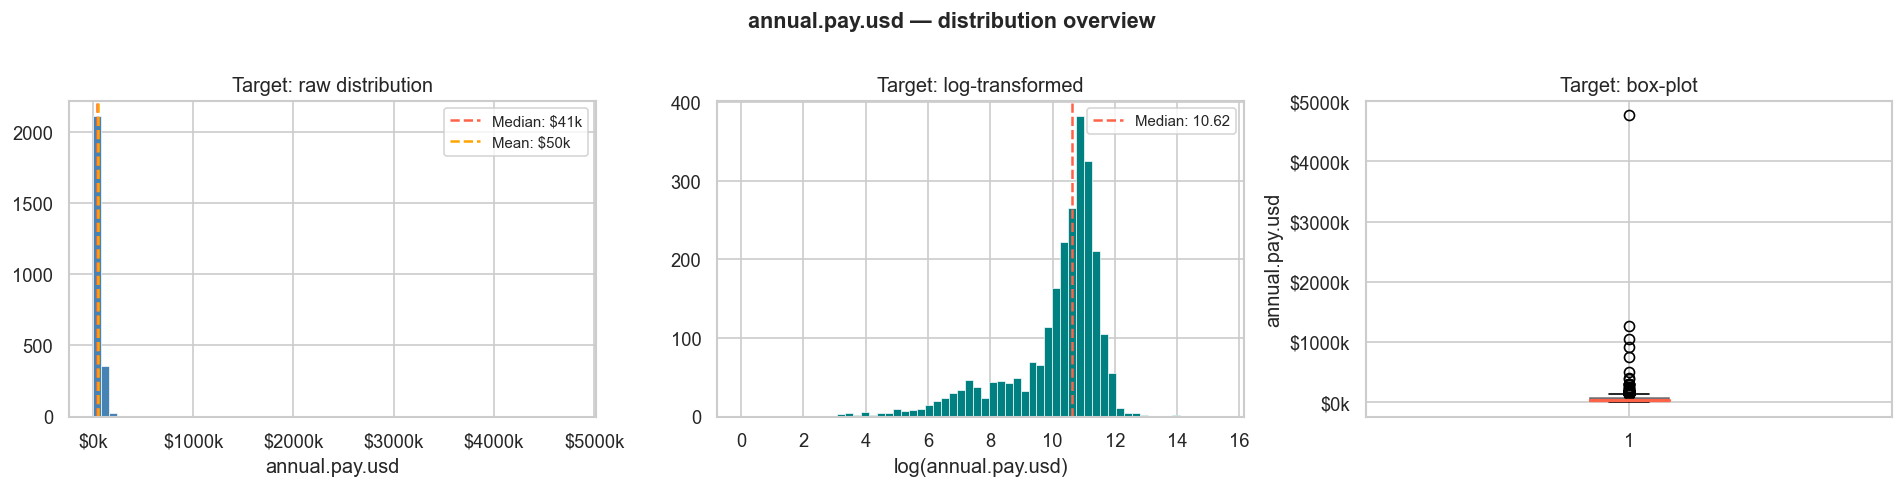

Raw target   — skewness: 33.134  |  kurtosis: 1384.799
Log target   — skewness: -1.661  |  kurtosis: 3.189

Note: log skewness is -1.66 (not ~0), driven by extreme low-value outliers in R17.
Per-region winsorization at P1/P99 will be applied to address this.

Percentiles:
  P 1: $        98
  P 5: $       834
  P25: $    16,217
  P50: $    40,828
  P75: $    65,589
  P95: $   118,863
  P99: $   177,388


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(df[TARGET].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Target: raw distribution')
axes[0].set_xlabel('annual.pay.usd')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].axvline(df[TARGET].median(), color='tomato', linewidth=1.5, linestyle='--',
                label=f'Median: ${df[TARGET].median()/1e3:.0f}k')
axes[0].axvline(df[TARGET].mean(), color='orange', linewidth=1.5, linestyle='--',
                label=f'Mean: ${df[TARGET].mean()/1e3:.0f}k')
axes[0].legend(fontsize=9)

# Log-transformed distribution
log_target = np.log(df[TARGET].dropna())
axes[1].hist(log_target, bins=60, color='teal', edgecolor='white', linewidth=0.4)
axes[1].set_title('Target: log-transformed')
axes[1].set_xlabel('log(annual.pay.usd)')
axes[1].axvline(log_target.median(), color='tomato', linewidth=1.5, linestyle='--',
                label=f'Median: {log_target.median():.2f}')
axes[1].legend(fontsize=9)

# Box-plot with outlier annotation
axes[2].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='tomato', linewidth=2))
axes[2].set_title('Target: box-plot')
axes[2].set_ylabel('annual.pay.usd')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('annual.pay.usd — distribution overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

raw = df[TARGET].dropna()
print(f'Raw target   — skewness: {raw.skew():.3f}  |  kurtosis: {raw.kurt():.3f}')
print(f'Log target   — skewness: {np.log(raw).skew():.3f}  |  kurtosis: {np.log(raw).kurt():.3f}')
print()
print('Note: log skewness is -1.66 (not ~0), driven by extreme low-value outliers in R17.')
print('Per-region winsorization at P1/P99 will be applied to address this.')
print()
print('Percentiles:')
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f'  P{p:2d}: ${np.percentile(raw, p):>10,.0f}')

In [6]:
# Outlier investigation: who are the extreme values?
q01 = df[TARGET].quantile(0.01)
q99 = df[TARGET].quantile(0.99)

print(f'Observations below P1  (< ${q01:,.0f}): {(df[TARGET] < q01).sum()}')
print(f'Observations above P99 (> ${q99:,.0f}): {(df[TARGET] > q99).sum()}')
print()
print('Bottom 10 salaries:')
print(df.nsmallest(10, TARGET)[[TARGET, 'region', 'employment.type', 'dev.role']].to_string())
print()
print('Top 10 salaries:')
print(df.nlargest(10, TARGET)[[TARGET, 'region', 'employment.type', 'dev.role']].to_string())

Observations below P1  (< $98): 26
Observations above P99 (> $177,388): 26

Bottom 10 salaries:
      annual.pay.usd region employment.type                                       dev.role
232              1.0    R17       Full-time                            Developer, back-end
1652            11.0    R17       Full-time                          Developer, QA or test
250             15.0    R17       Full-time                            Developer, back-end
1959            21.0    R17       Full-time                           Developer, front-end
312             25.0    R11       Full-time                          Developer, full-stack
396             25.0    R17       Full-time                          Developer, full-stack
1553            26.0    R17       Full-time                    Developer, game or graphics
288             31.0    R17       Full-time                          Developer, QA or test
371             33.0    R17       Full-time  Developer, desktop or enterprise applica

## 4. R17 anomaly & outlier treatment

R17 contains **44% of all observations** (n=1,108). Both the bottom salaries ($1–$33) AND the top salaries (up to $4.77M) are concentrated in R17. This extreme within-region spread strongly suggests **currency mixing** — respondents reporting in local currency rather than USD. This is the most critical data quality issue and must be resolved before modeling.

In [7]:
# R17 vs rest of dataset
r17_mask = df['region'] == 'R17'
r17 = df.loc[r17_mask, TARGET]
other = df.loc[~r17_mask, TARGET]

print(f'R17 observations : {r17_mask.sum()} ({r17_mask.mean()*100:.1f}% of dataset)')
print(f'All other regions: {(~r17_mask).sum()} ({(~r17_mask).mean()*100:.1f}% of dataset)')
print()
print(f'           {"R17":>15} {"Other regions":>15}')
print(f'  Min    : {r17.min():>15,.0f} {other.min():>15,.0f}')
print(f'  P1     : {r17.quantile(0.01):>15,.0f} {other.quantile(0.01):>15,.0f}')
print(f'  Median : {r17.median():>15,.0f} {other.median():>15,.0f}')
print(f'  Mean   : {r17.mean():>15,.0f} {other.mean():>15,.0f}')
print(f'  P99    : {r17.quantile(0.99):>15,.0f} {other.quantile(0.99):>15,.0f}')
print(f'  Max    : {r17.max():>15,.0f} {other.max():>15,.0f}')
print(f'  Std    : {r17.std():>15,.0f} {other.std():>15,.0f}')
print()
print(f'Median/mean gap in R17: ${r17.mean() - r17.median():,.0f}  (large gap signals extreme outliers)')

R17 observations : 1108 (44.1% of dataset)
All other regions: 1404 (55.9% of dataset)

                       R17   Other regions
  Min    :               1              25
  P1     :              39             651
  Median :          26,930          49,724
  Mean   :          41,102          56,508
  P99    :         160,983         189,500
  Max    :       4,773,360       1,042,782
  Std    :         153,110          53,884

Median/mean gap in R17: $14,172  (large gap signals extreme outliers)


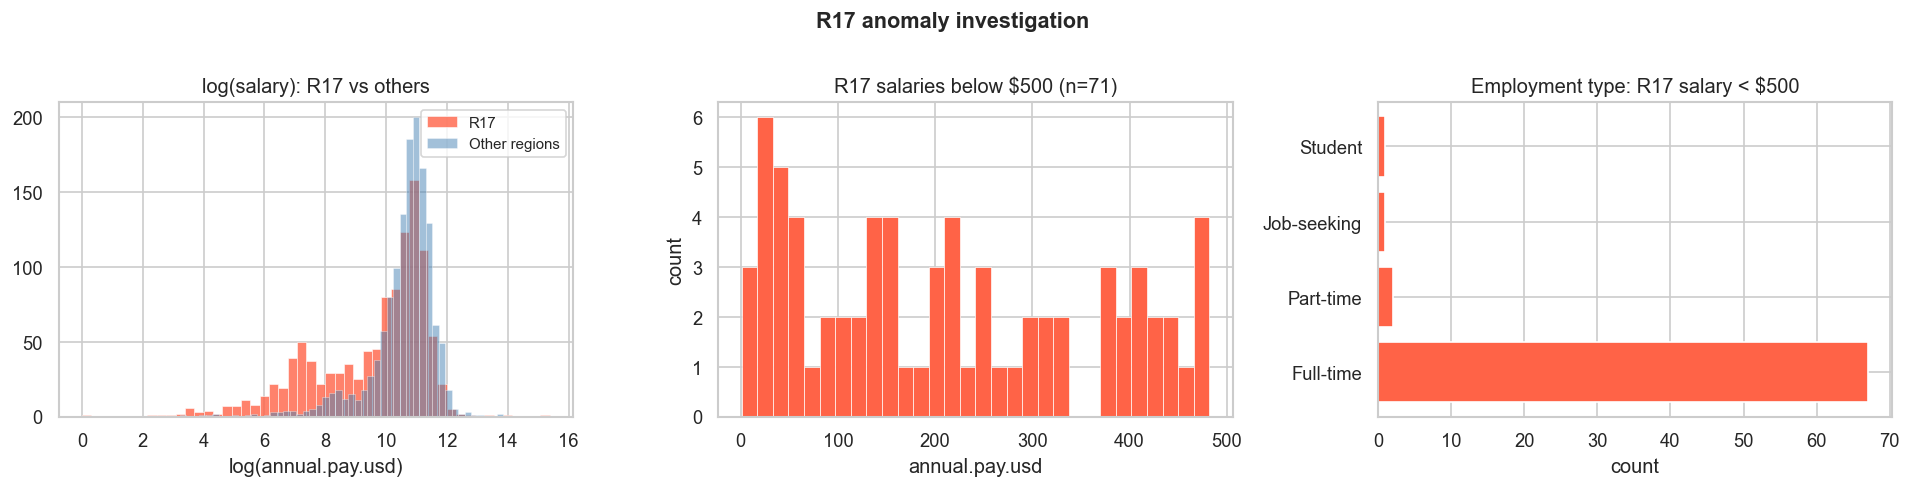

R17 obs with salary < $500  : 71
R17 obs with salary < $1000 : 130
R17 obs with salary > $200k : 6


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log salary: R17 vs others overlaid
axes[0].hist(np.log(r17.clip(lower=1)), bins=50, color='tomato', edgecolor='white',
             linewidth=0.4, alpha=0.8, label='R17')
axes[0].hist(np.log(other.clip(lower=1)), bins=50, color='steelblue', edgecolor='white',
             linewidth=0.4, alpha=0.5, label='Other regions')
axes[0].set_title('log(salary): R17 vs others')
axes[0].set_xlabel('log(annual.pay.usd)')
axes[0].legend(fontsize=9)

# Extreme low values in R17
low_r17 = r17[r17 < 500]
axes[1].hist(low_r17, bins=30, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].set_title(f'R17 salaries below $500 (n={len(low_r17)})')
axes[1].set_xlabel('annual.pay.usd')
axes[1].set_ylabel('count')

# Employment type for extreme low R17
low_r17_df = df.loc[r17_mask & (df[TARGET] < 500)]
emp_counts = low_r17_df['employment.type'].value_counts()
axes[2].barh(emp_counts.index, emp_counts.values, color='tomato', edgecolor='white')
axes[2].set_title('Employment type: R17 salary < $500')
axes[2].set_xlabel('count')

plt.suptitle('R17 anomaly investigation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'R17 obs with salary < $500  : {(r17 < 500).sum()}')
print(f'R17 obs with salary < $1000 : {(r17 < 1000).sum()}')
print(f'R17 obs with salary > $200k : {(r17 > 200000).sum()}')

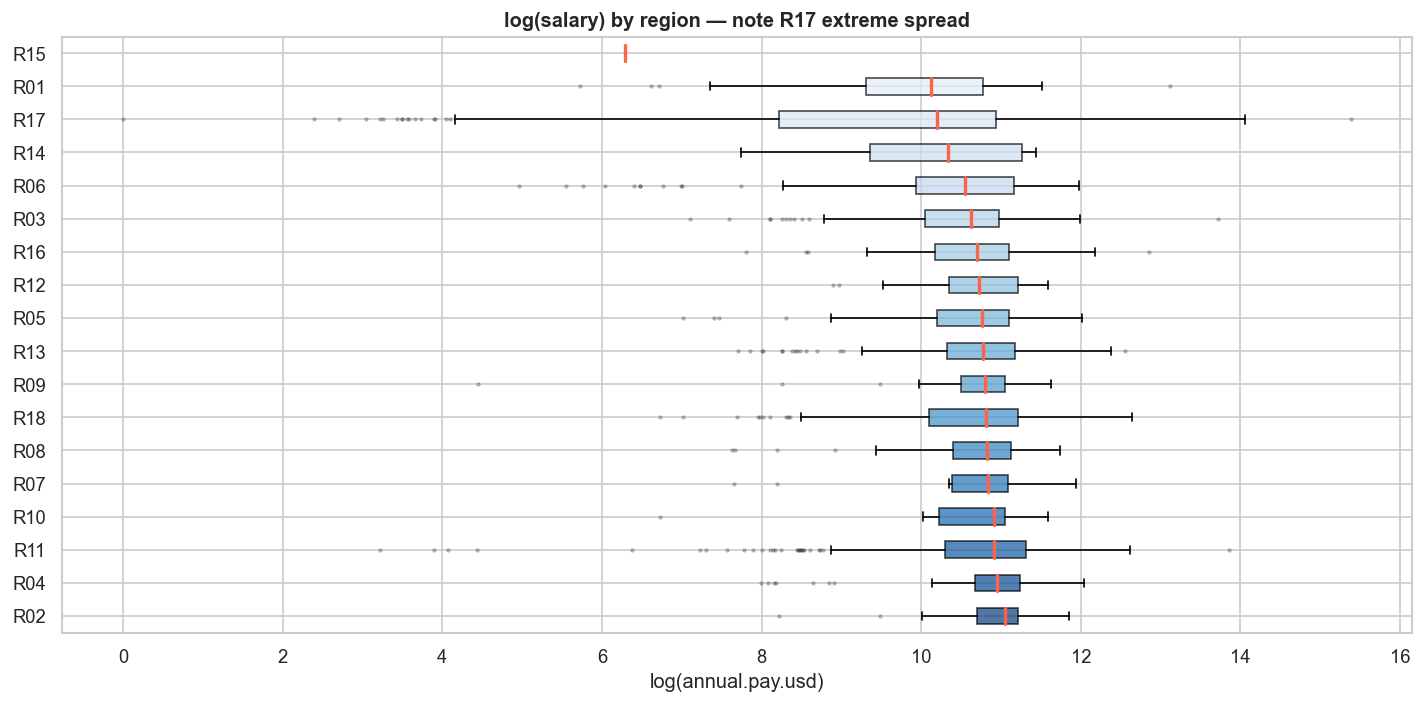

In [9]:
# All regions on log scale — R17 spread is clearly the widest
region_order = df.groupby('region')[TARGET].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
data_by_region = [np.log(df.loc[df['region'] == r, TARGET].dropna().clip(lower=1)) for r in region_order]
bp = ax.boxplot(data_by_region, vert=False, patch_artist=True,
                medianprops=dict(color='tomato', linewidth=2),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
colors = sns.color_palette('Blues_r', n_colors=len(region_order))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_yticks(range(1, len(region_order)+1))
ax.set_yticklabels(region_order)
ax.set_xlabel('log(annual.pay.usd)')
ax.set_title('log(salary) by region — note R17 extreme spread', fontweight='bold')
plt.tight_layout()
plt.show()

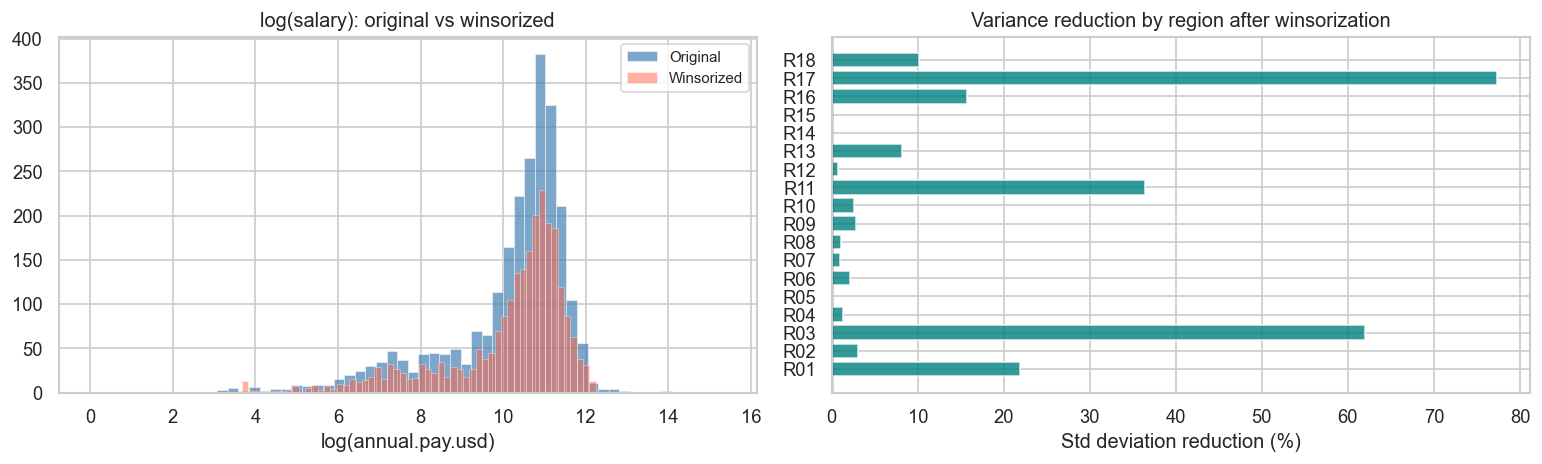

Log skewness — original   : -1.661
Log skewness — winsorized : -1.605

Top 5 regions by variance reduction:
         original_std  winsorized_std  std_reduction_pct
region                                                  
R17     153109.671866    34703.311850               77.3
R03      87044.684252    33093.148649               62.0
R11      63108.034201    40145.886909               36.4
R01      89762.876525    70134.952815               21.9
R16      59593.074229    50244.665818               15.7

DECISION: Apply per-region P1/P99 winsorization before modeling.
Modeling target: log(winsorized annual.pay.usd)


In [10]:
# Outlier treatment: winsorize per region at P1/P99
# Global winsorization would distort legitimate salary differences across regions.
# Per-region winsorization preserves the regional salary structure.

def winsorize_per_region(df, target, lower_q=0.01, upper_q=0.99):
    df_out = df.copy()
    for region in df['region'].unique():
        mask = df['region'] == region
        lo = df.loc[mask, target].quantile(lower_q)
        hi = df.loc[mask, target].quantile(upper_q)
        df_out.loc[mask, target] = df.loc[mask, target].clip(lower=lo, upper=hi)
    return df_out

df_wins = winsorize_per_region(df, TARGET)

raw_log = np.log(df[TARGET].dropna())
wins_log = np.log(df_wins[TARGET].dropna())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before vs after
axes[0].hist(raw_log, bins=60, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.7, label='Original')
axes[0].hist(wins_log, bins=60, color='tomato', edgecolor='white', linewidth=0.4, alpha=0.5, label='Winsorized')
axes[0].set_title('log(salary): original vs winsorized')
axes[0].set_xlabel('log(annual.pay.usd)')
axes[0].legend(fontsize=9)

# Variance reduction per region
region_comparison = pd.DataFrame({
    'original_std': df.groupby('region')[TARGET].std(),
    'winsorized_std': df_wins.groupby('region')[TARGET].std(),
})
region_comparison['std_reduction_pct'] = (
    (region_comparison['original_std'] - region_comparison['winsorized_std'])
    / region_comparison['original_std'] * 100
).round(1)

axes[1].barh(region_comparison.index, region_comparison['std_reduction_pct'],
             color='teal', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Std deviation reduction (%)')
axes[1].set_title('Variance reduction by region after winsorization')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f'Log skewness — original   : {raw_log.skew():.3f}')
print(f'Log skewness — winsorized : {wins_log.skew():.3f}')
print()
print('Top 5 regions by variance reduction:')
print(region_comparison.sort_values('std_reduction_pct', ascending=False).head(5).to_string())
print()
print('DECISION: Apply per-region P1/P99 winsorization before modeling.')
print('Modeling target: log(winsorized annual.pay.usd)')

## 5. Missing values

In [11]:
# Missing value counts and percentages
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(miss_df)} / {df.shape[1]}')
print()
print(miss_df.to_string())

Columns with missing values: 32 / 41

                           missing_n  missing_pct
cloud.hosting                    900         35.8
daily.answer.time                888         35.4
daily.search.time                886         35.3
first.help.source                883         35.2
industry                         879         35.0
job.satisfaction                 867         34.5
experience.years                 863         34.4
people.manager                   859         34.2
other.tech                       853         34.0
ai.tools.used                    850         33.8
ai.complex.rating                781         31.1
ai.trust                         771         30.7
web.frameworks                   581         23.1
cloud.platforms                  554         22.1
ai.search.tools                  485         19.3
ai.sentiment                     444         17.7
ai.job.threat                    443         17.6
databases                        306         12.2
project.mgmt

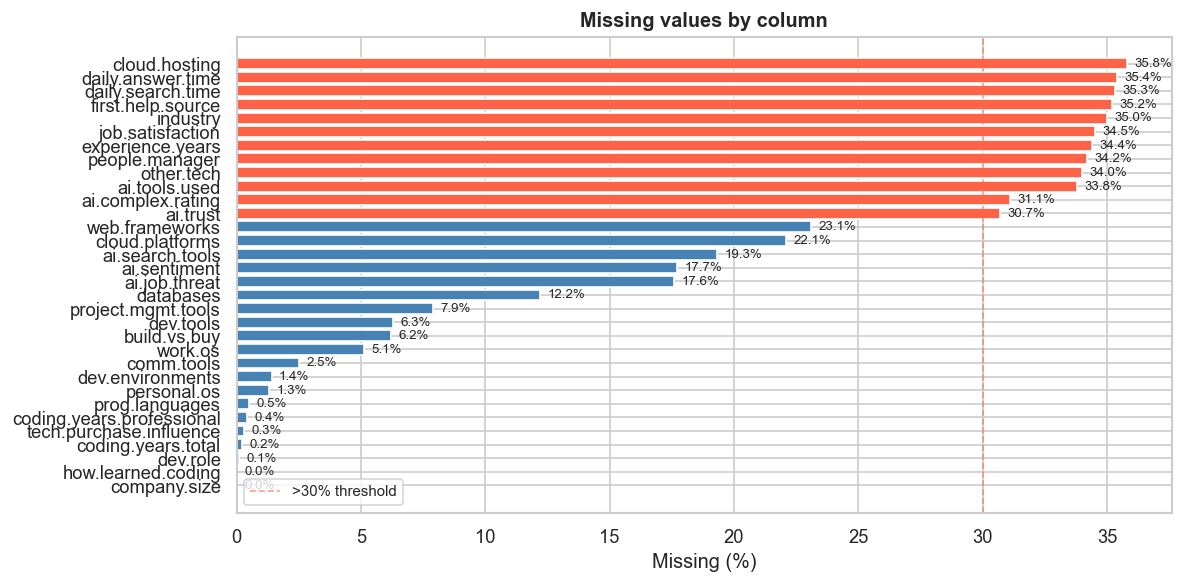

In [12]:
# Missing values bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if p > 30 else 'steelblue' for p in miss_df['missing_pct']]
bars = ax.barh(miss_df.index, miss_df['missing_pct'], color=colors, edgecolor='white')
ax.axvline(30, color='tomato', linestyle='--', linewidth=1, alpha=0.6, label='>30% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values by column', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, pct in zip(bars, miss_df['missing_pct']):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# Missingness vs salary: MCAR or informative (MNAR/MAR)?
high_miss_cols = miss_df[miss_df['missing_pct'] > 5].index.tolist()
high_miss_cols = [c for c in high_miss_cols if c in df.columns and c != TARGET]

print('Median salary — present vs missing rows:')
print(f'{"Column":<30} {"Present":>18} {"Missing":>18} {"Diff %":>10} {"Type":>14}')
print('-' * 95)
for col in high_miss_cols[:12]:
    m_present = df.loc[df[col].notna(), TARGET].median()
    m_missing = df.loc[df[col].isna(), TARGET].median()
    if pd.notna(m_present) and pd.notna(m_missing) and m_present != 0:
        diff = (m_missing - m_present) / m_present * 100
        interp = 'INFORMATIVE' if abs(diff) > 10 else 'likely MCAR'
        print(f'{col:<30} {m_present:>18,.0f} {m_missing:>18,.0f} {diff:>+10.1f}% {interp:>14}')

print()
print('KEY INSIGHT: ai.trust, ai.complex.rating, ai.tools.used are MNAR.')
print('These columns are only shown to users who use AI tools (uses.ai=Yes).')
print('Non-users who skip them may be senior/higher-paid developers.')
print('ACTION: Add binary missingness indicator columns for all columns >10% missing.')

Median salary — present vs missing rows:
Column                                    Present            Missing     Diff %           Type
-----------------------------------------------------------------------------------------------
cloud.hosting                              43,226             36,450      -15.7%    INFORMATIVE
daily.answer.time                          42,925             36,607      -14.7%    INFORMATIVE
daily.search.time                          42,816             36,719      -14.2%    INFORMATIVE
first.help.source                          42,951             36,470      -15.1%    INFORMATIVE
industry                                   43,044             36,429      -15.4%    INFORMATIVE
job.satisfaction                           42,865             36,653      -14.5%    INFORMATIVE
experience.years                           42,899             36,561      -14.8%    INFORMATIVE
people.manager                             42,865             36,653      -14.5%    INFORMATIVE


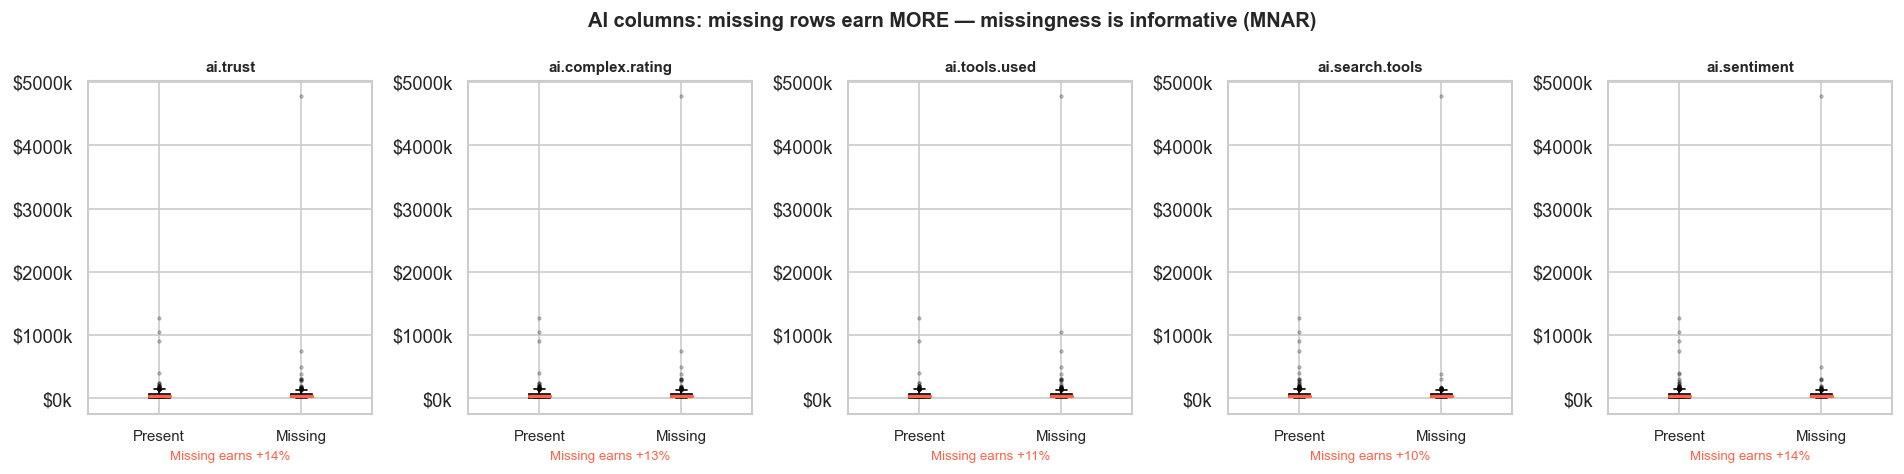

In [14]:
# Visualize the counterintuitive AI-column missingness pattern
ai_miss_cols = ['ai.trust', 'ai.complex.rating', 'ai.tools.used', 'ai.search.tools', 'ai.sentiment']

fig, axes = plt.subplots(1, len(ai_miss_cols), figsize=(16, 4))
for ax, col in zip(axes, ai_miss_cols):
    present_sal = df.loc[df[col].notna(), TARGET].dropna()
    missing_sal = df.loc[df[col].isna(), TARGET].dropna()
    ax.boxplot([present_sal, missing_sal], patch_artist=True,
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels(['Present', 'Missing'], fontsize=9)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    pres_med = present_sal.median()
    miss_med = missing_sal.median()
    diff_pct = (miss_med - pres_med) / pres_med * 100
    ax.set_xlabel(f'Missing earns {diff_pct:+.0f}%', fontsize=8, color='tomato')

plt.suptitle('AI columns: missing rows earn MORE — missingness is informative (MNAR)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Numeric features

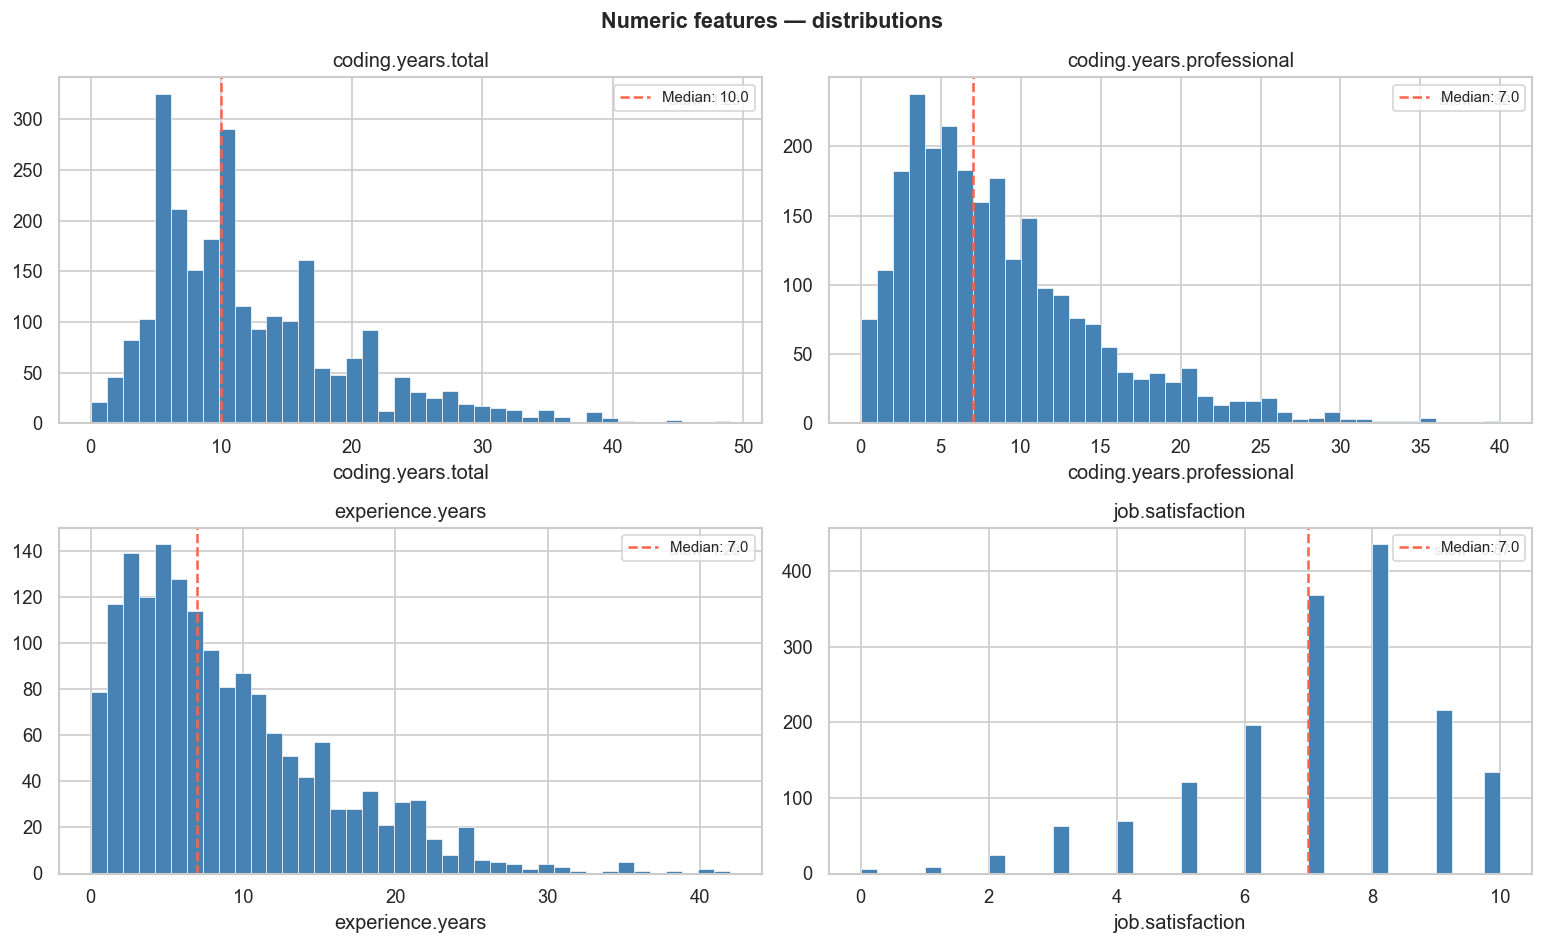

In [15]:
# Distributions of numeric features
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(data.median(), color='tomato', linewidth=1.5,
                    linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=9)
    axes[i].annotate(f'skew={data.skew():.2f}', xy=(0.97, 0.92),
                     xycoords='axes fraction', ha='right', fontsize=9, color='gray')

plt.suptitle('Numeric features — distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

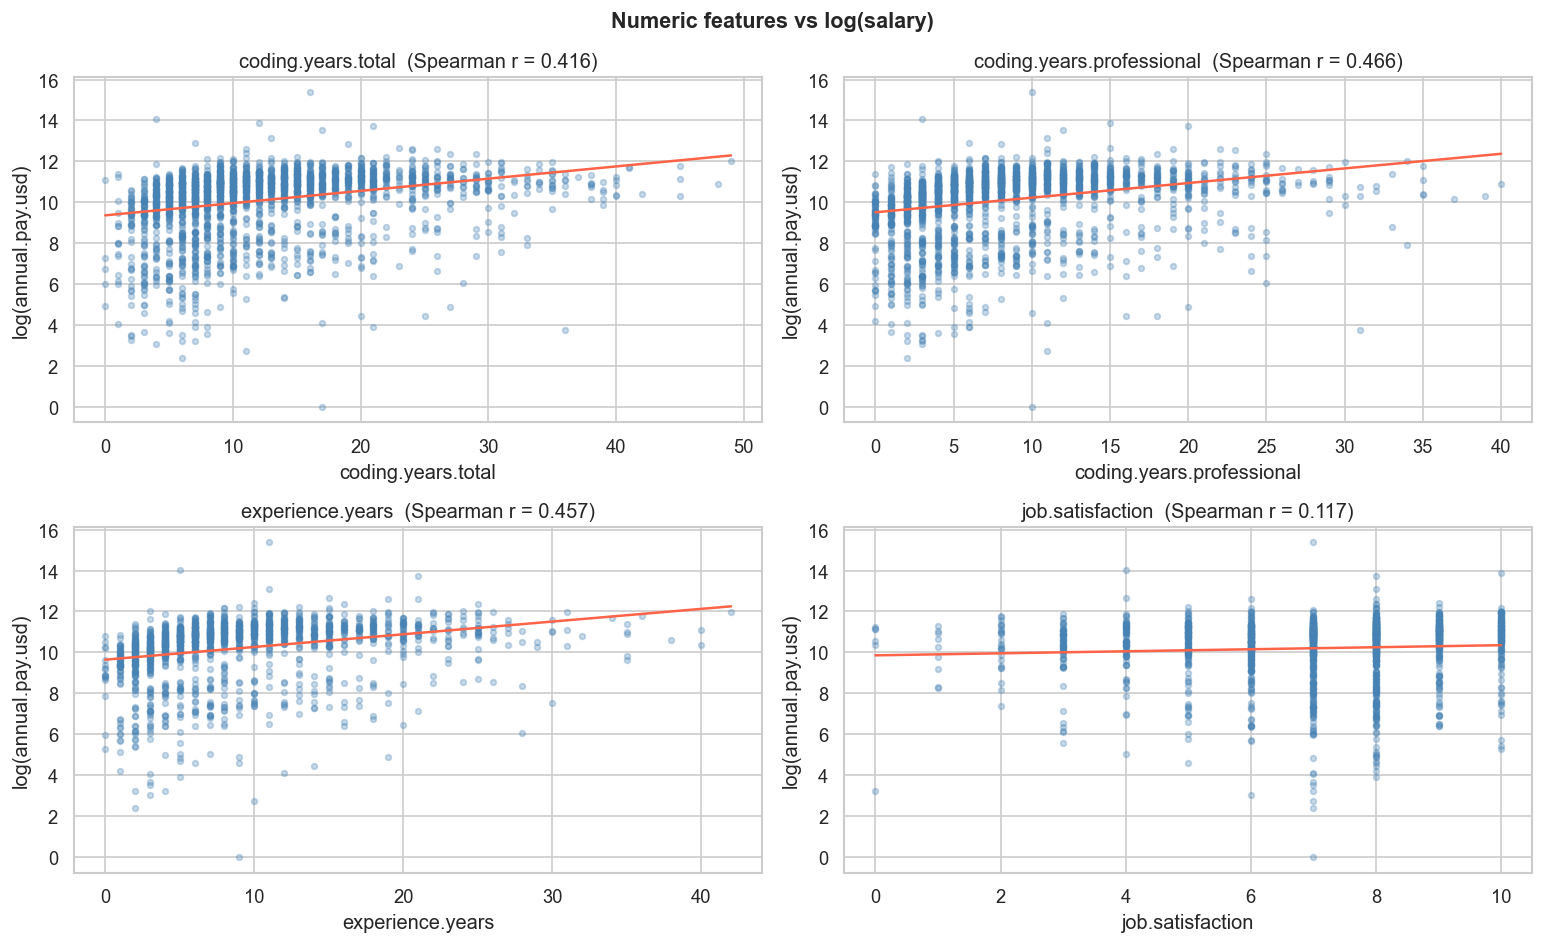

In [16]:
# Scatter plots vs log(target)
log_y = np.log(df[TARGET])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    mask = df[col].notna() & df[TARGET].notna()
    x = df.loc[mask, col]
    y = log_y[mask]
    axes[i].scatter(x, y, alpha=0.3, s=12, color='steelblue')
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xline, p(xline), color='tomato', linewidth=1.5)
    corr = x.corr(y, method='spearman')
    axes[i].set_title(f'{col}  (Spearman r = {corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(annual.pay.usd)')

plt.suptitle('Numeric features vs log(salary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

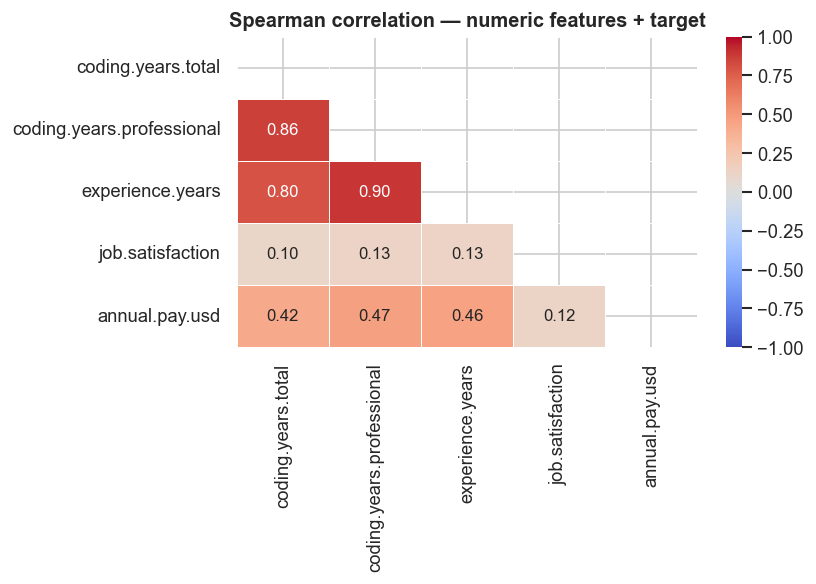

coding.years.total vs coding.years.professional : r = 0.86
experience.years   vs coding.years.professional : r = 0.90

DECISION: r=0.86-0.90 is severe multicollinearity.
  Drop: coding.years.total
  Keep: coding.years.professional, experience.years
  Engineer: years.before.professional = coding.years.total - coding.years.professional
  (captures pre-career coding years, orthogonal to professional experience)


In [17]:
# Spearman heatmap — confirms severe multicollinearity
num_df = df[NUMERIC_COLS + [TARGET]].copy()
corr_matrix = num_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Spearman correlation — numeric features + target', fontweight='bold')
plt.tight_layout()
plt.show()

r_total_prof = corr_matrix.loc['coding.years.total', 'coding.years.professional']
r_exp_prof   = corr_matrix.loc['experience.years',   'coding.years.professional']
print(f'coding.years.total vs coding.years.professional : r = {r_total_prof:.2f}')
print(f'experience.years   vs coding.years.professional : r = {r_exp_prof:.2f}')
print()
print('DECISION: r=0.86-0.90 is severe multicollinearity.')
print('  Drop: coding.years.total')
print('  Keep: coding.years.professional, experience.years')
print('  Engineer: years.before.professional = coding.years.total - coding.years.professional')
print('  (captures pre-career coding years, orthogonal to professional experience)')

## 7. Ordinal features

In [18]:
# Ordinal encodings — reused in feature engineering notebook
ORDINAL_MAPS = {
    'age.group': {
        '18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4
    },
    'education': {
        'Primary/elementary school': 0,
        'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
        'Some college/university study without earning a degree': 2,
        'Associate degree (A.A., A.S., etc.)': 3,
        'Something else': 3,
        'Bachelor\'s degree (B.A., B.S., B.Eng., etc.)': 4,
        'Master\'s degree (M.A., M.S., M.Eng., MBA, etc.)': 5,
        'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6
    },
    'company.size': {
        'Just me - I am a freelancer, sole proprietor, etc.': 0,
        '2 to 9 employees': 1,
        '10 to 19 employees': 2,
        '20 to 99 employees': 3,
        '100 to 499 employees': 4,
        '500 to 999 employees': 5,
        '1,000 to 4,999 employees': 6,
        '5,000 to 9,999 employees': 7,
        '10,000 or more employees': 8
    },
    'tech.purchase.influence': {
        'I have little or no influence': 0,
        'I have some influence': 1,
        'I have a great deal of influence': 2
    },
    'ai.sentiment': {
        'Very unfavorable': 0, 'Unfavorable': 1, 'Indifferent': 2,
        'Unsure': 2, 'Favorable': 3, 'Very favorable': 4
    },
    'ai.trust': {
        'Highly distrust': 0, 'Somewhat distrust': 1,
        'Neither trust nor distrust': 2,
        'Somewhat trust': 3, 'Highly trust': 4
    },
    'ai.complex.rating': {
        'Very poor at handling complex tasks': 0,
        'Bad at handling complex tasks': 1,
        'Neither good or bad at handling complex tasks': 2,
        'Good, but not great at handling complex tasks': 3,
        'Very well at handling complex tasks': 4
    },
    'daily.search.time': {
        'Less than 15 minutes a day': 0, '15-30 minutes a day': 1,
        '30-60 minutes a day': 2, '60-120 minutes a day': 3, 'Over 120 minutes a day': 4
    },
    'daily.answer.time': {
        'Less than 15 minutes a day': 0, '15-30 minutes a day': 1,
        '30-60 minutes a day': 2, '60-120 minutes a day': 3, 'Over 120 minutes a day': 4
    }
}

print(f'Ordinal encodings defined for {len(ORDINAL_MAPS)} columns.')

Ordinal encodings defined for 9 columns.


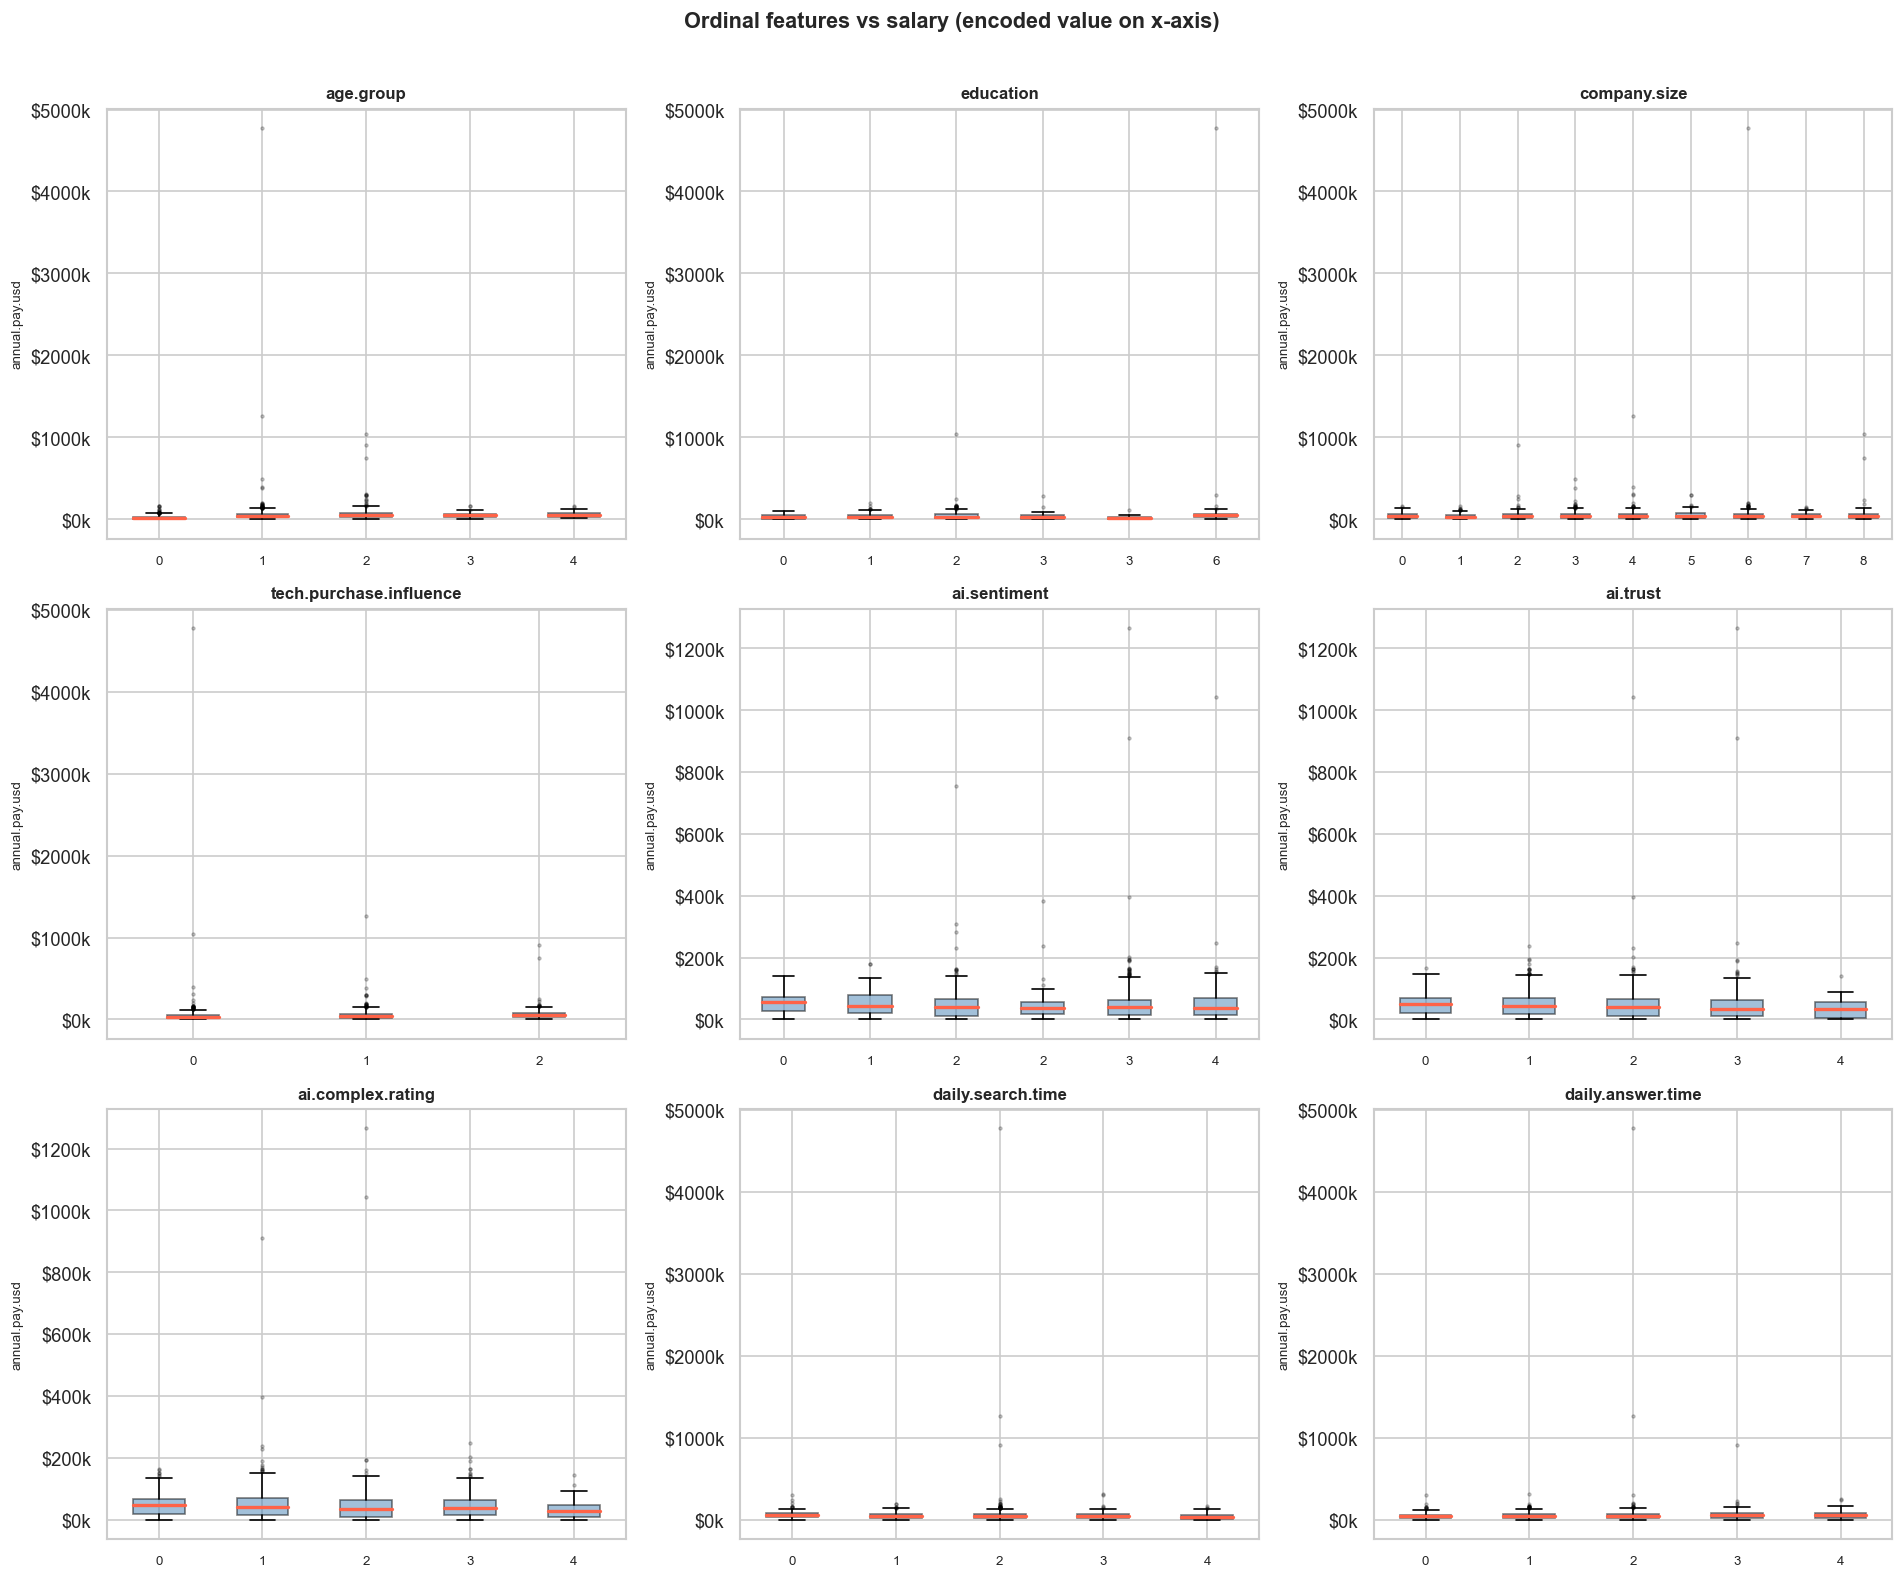

In [19]:
# Box-plots: ordinal feature vs salary
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(ORDINAL_MAPS.keys()):
    ax = axes[i]
    order = list(ORDINAL_MAPS[col].keys())
    present = [k for k in order if k in df[col].values]
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in present]
    ax.boxplot(data_list, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels([str(ORDINAL_MAPS[col][k]) for k in present], fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('annual.pay.usd', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Ordinal features vs salary (encoded value on x-axis)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Spearman correlation of encoded ordinals with target
print('Spearman correlation with annual.pay.usd:')
print(f'{"Column":<30} {"Spearman r":>12}')
print('-' * 44)
for col, mapping in ORDINAL_MAPS.items():
    enc = df[col].map(mapping)
    corr = enc.corr(df[TARGET], method='spearman')
    print(f'{col:<30} {corr:>12.4f}')

Spearman correlation with annual.pay.usd:
Column                           Spearman r
--------------------------------------------
age.group                            0.2967
education                            0.0616
company.size                         0.0861
tech.purchase.influence              0.1383
ai.sentiment                        -0.0066
ai.trust                            -0.0795
ai.complex.rating                   -0.0718
daily.search.time                   -0.0840
daily.answer.time                    0.1230


## 8. Nominal / categorical features

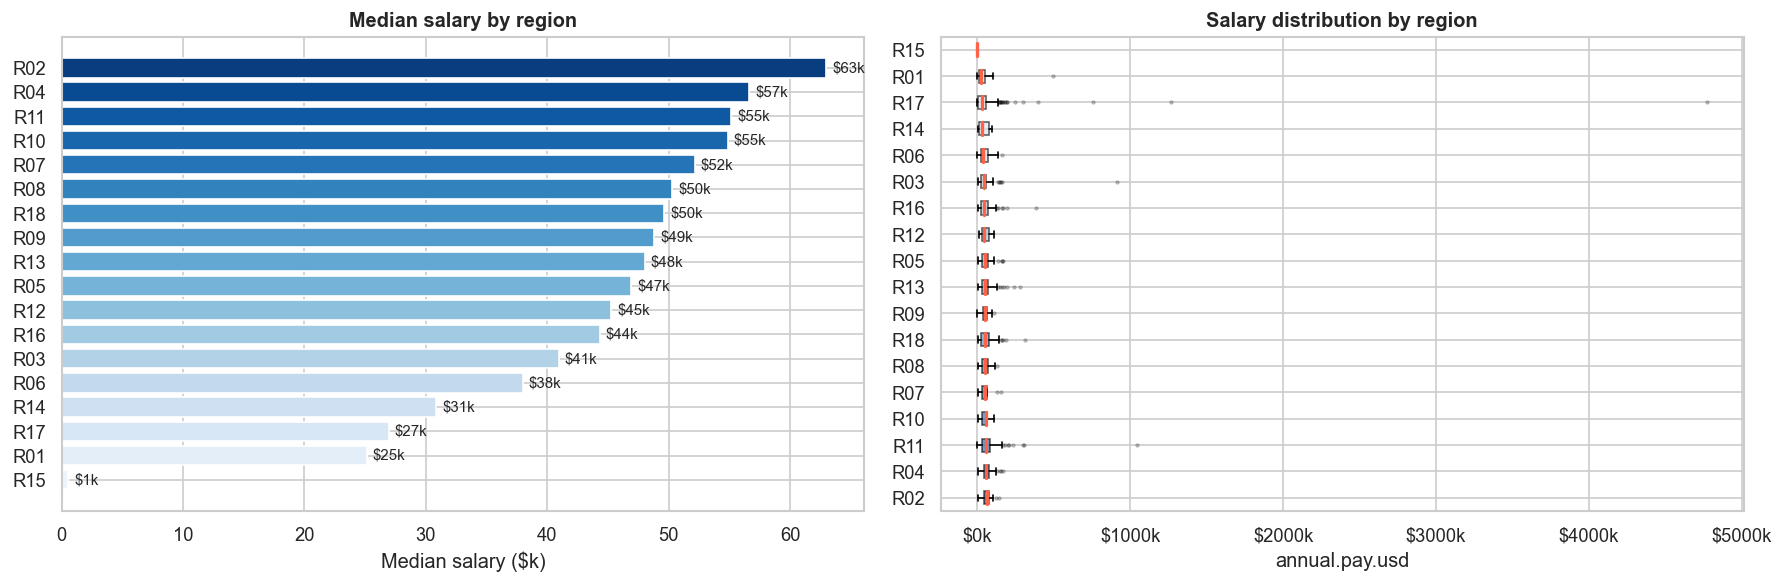

Region summary:
        median_salary   mean_salary  count
region                                    
R02           62965.0  60835.738095     42
R04           56653.0  62285.616667     60
R11           55155.0  63109.085450    433
R10           54868.5  50978.666667      6
R07           52139.5  58900.000000     10
R08           50284.0  50714.824561     57
R18           49654.5  56833.893443    122
R09           48821.0  49855.677966     59
R13           48023.5  54801.084906    212
R05           46913.5  50368.500000     80
R12           45278.0  50968.766667     30
R16           44334.0  60246.750000     60
R03           40937.5  51486.675439    114
R06           37977.0  45936.626667     75
R14           30870.0  42340.692308     13
R17           26930.5  41102.259928   1108
R01           25131.5  46716.066667     30
R15             537.0    537.000000      1


In [21]:
# Region: median salary bar chart and box-plots
region_stats = df.groupby('region')[TARGET].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
region_stats.columns = ['median_salary', 'mean_salary', 'count']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = sns.color_palette('Blues_r', n_colors=len(region_stats))
axes[0].barh(region_stats.index, region_stats['median_salary'] / 1e3, color=colors, edgecolor='white')
axes[0].set_xlabel('Median salary ($k)')
axes[0].set_title('Median salary by region', fontweight='bold')
axes[0].invert_yaxis()
for y, val in zip(range(len(region_stats)), region_stats['median_salary']):
    axes[0].text(val/1e3 + 0.5, y, f'${val/1e3:.0f}k', va='center', fontsize=9)

region_order_plot = region_stats.index.tolist()
data_by_region = [df.loc[df['region'] == r, TARGET].dropna() for r in region_order_plot]
bp = axes[1].boxplot(data_by_region, vert=False, patch_artist=True,
                     medianprops=dict(color='tomato', linewidth=2),
                     flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_yticks(range(1, len(region_order_plot)+1))
axes[1].set_yticklabels(region_order_plot)
axes[1].set_xlabel('annual.pay.usd')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].set_title('Salary distribution by region', fontweight='bold')

plt.tight_layout()
plt.show()

print('Region summary:')
print(region_stats.to_string())

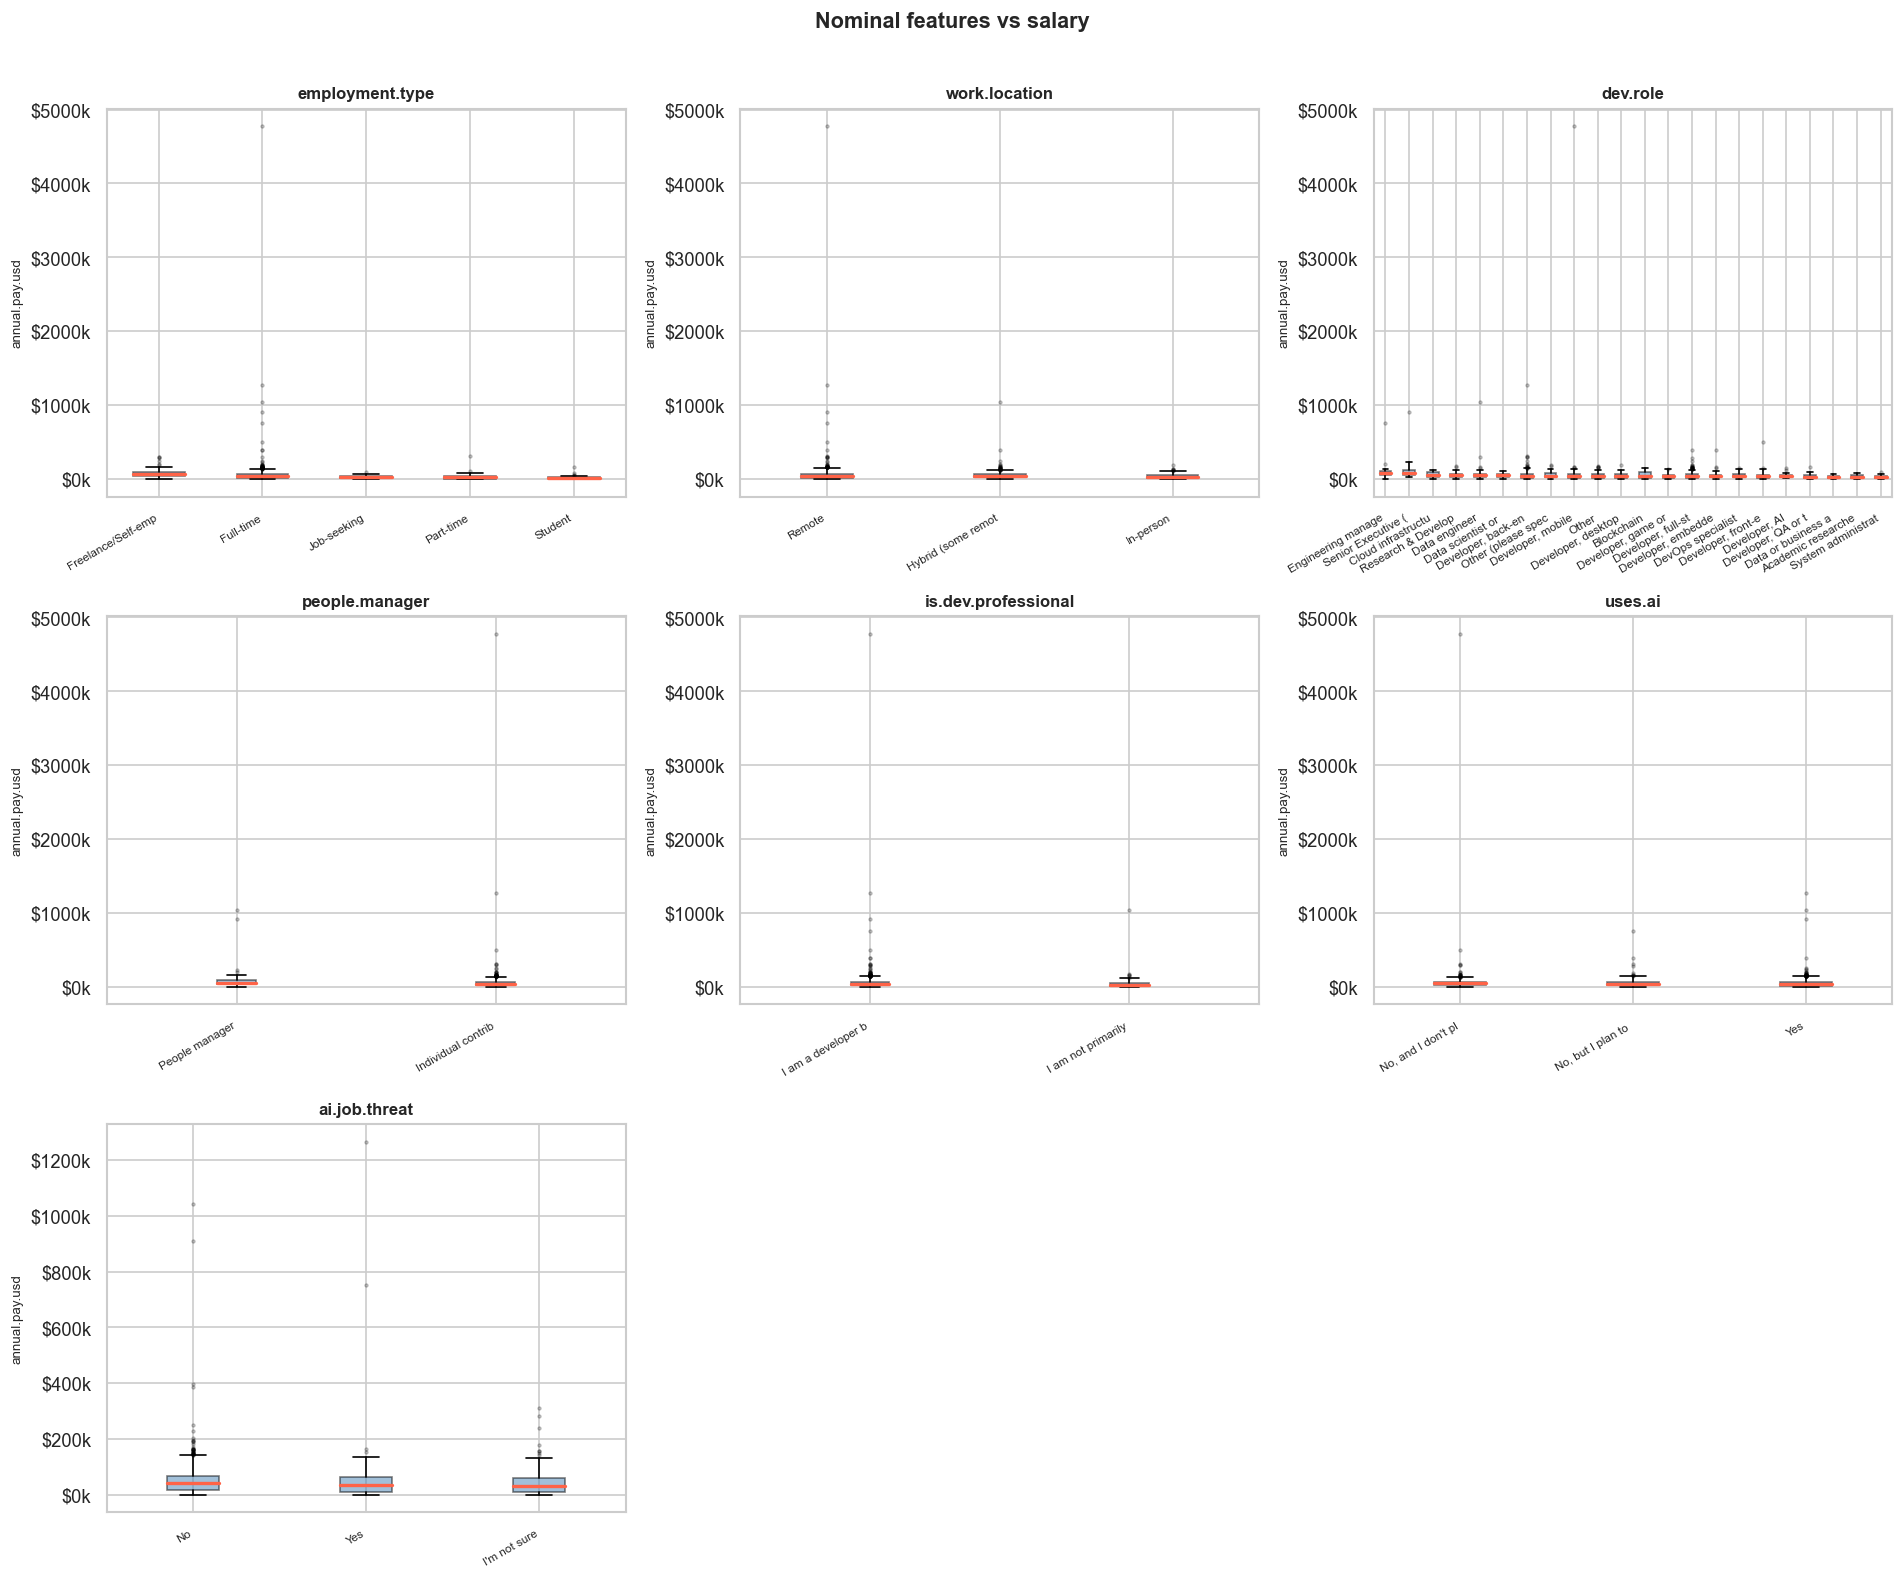

In [22]:
# Other nominal features vs salary
nominal_to_plot = ['employment.type', 'work.location', 'dev.role', 'people.manager',
                   'is.dev.professional', 'uses.ai', 'ai.job.threat']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(nominal_to_plot):
    ax = axes[i]
    order = (df.groupby(col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in order]
    ax.boxplot(data_list, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels([str(k)[:18] for k in order], rotation=30, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('annual.pay.usd', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

for j in range(len(nominal_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Nominal features vs salary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

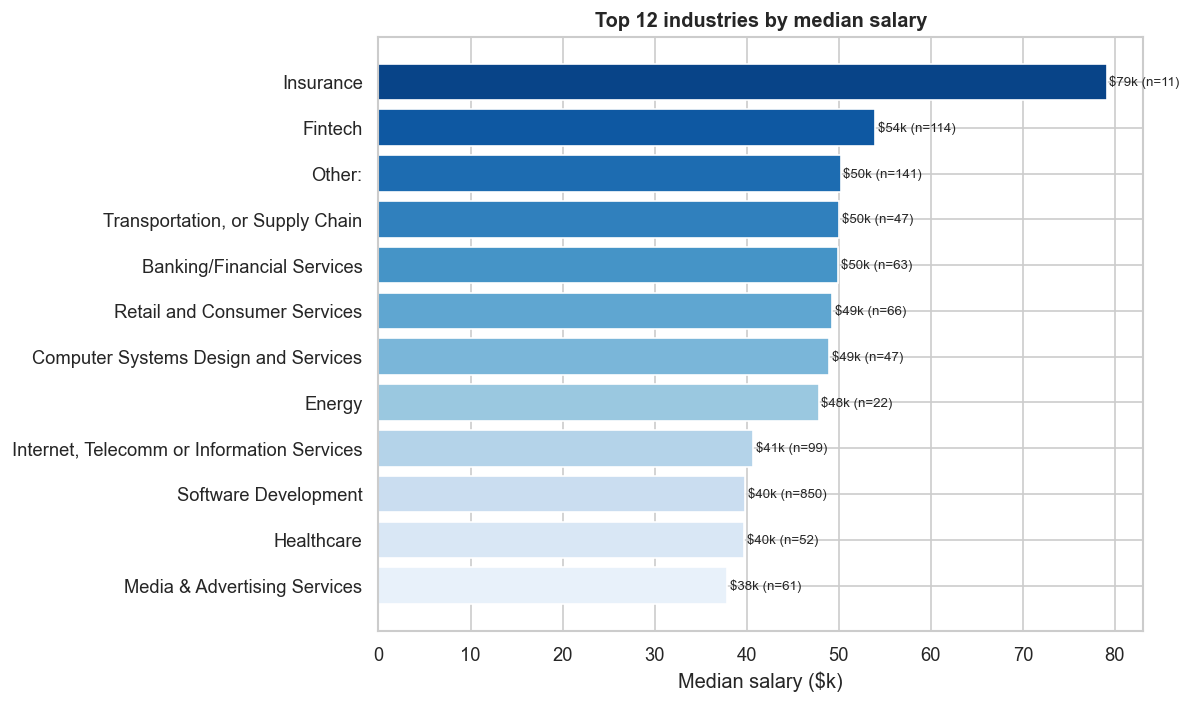

Industries with n<20: 3 — group as "Other" in feature engineering.


In [23]:
# Top industries by median salary
industry_stats = (df.groupby('industry')[TARGET]
                    .agg(['median', 'count'])
                    .sort_values('median', ascending=False))
top_n = 12
plot_df = industry_stats.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df.index, plot_df['median'] / 1e3,
        color=sns.color_palette('Blues_r', n_colors=top_n), edgecolor='white')
ax.set_xlabel('Median salary ($k)')
ax.set_title(f'Top {top_n} industries by median salary', fontweight='bold')
ax.invert_yaxis()
for y, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['median']/1e3 + 0.3, y,
            f'${row["median"]/1e3:.0f}k (n={int(row["count"])})', va='center', fontsize=8)
plt.tight_layout()
plt.show()

small_industries = industry_stats[industry_stats['count'] < 20]
print(f'Industries with n<20: {len(small_industries)} — group as "Other" in feature engineering.')

## 9. Multi-select (technology stack) features

In [24]:
# Helper functions for multi-select columns
def parse_multiselect(series, sep=';'):
    items = []
    for val in series.dropna():
        items.extend([x.strip() for x in str(val).split(sep)])
    return Counter(items)

def multiselect_salary_analysis(df, col, top_n=15, target=TARGET):
    item_salaries = {}
    for _, row in df.iterrows():
        if pd.isna(row[col]) or pd.isna(row[target]):
            continue
        for item in str(row[col]).split(';'):
            item = item.strip()
            if item not in item_salaries:
                item_salaries[item] = []
            item_salaries[item].append(row[target])
    result = {
        k: {'count': len(v), 'median': np.median(v), 'mean': np.mean(v)}
        for k, v in item_salaries.items() if len(v) >= 10
    }
    return pd.DataFrame(result).T.sort_values('median', ascending=False).head(top_n)

print('Helper functions defined.')

Helper functions defined.


In [25]:
# Unique item counts and average selections per row
print(f'{"Column":<30} {"Missing%":>10} {"Unique items":>15} {"Avg per row":>12}')
print('-' * 70)
for col in MULTI_SELECT_COLS:
    missing_pct = df[col].isna().mean() * 100
    counter = parse_multiselect(df[col])
    n_unique = len(counter)
    avg_per_row = np.mean([len(str(v).split(';')) for v in df[col].dropna()])
    print(f'{col:<30} {missing_pct:>9.1f}% {n_unique:>15} {avg_per_row:>12.1f}')

Column                           Missing%    Unique items  Avg per row
----------------------------------------------------------------------
side.coding                          0.0%               8          1.9
how.learned.coding                   0.0%               9          3.4
prog.languages                       0.5%              40          4.6
databases                           12.2%              29          3.2
cloud.platforms                     22.1%              25          2.2
web.frameworks                      23.1%              34          3.3
other.tech                          34.0%              37          2.6
dev.tools                            6.3%              34          4.4
dev.environments                     1.4%              33          3.2
personal.os                          1.3%              17          2.0
work.os                              5.1%              14          1.8
project.mgmt.tools                   7.9%              24          2.8
comm.t

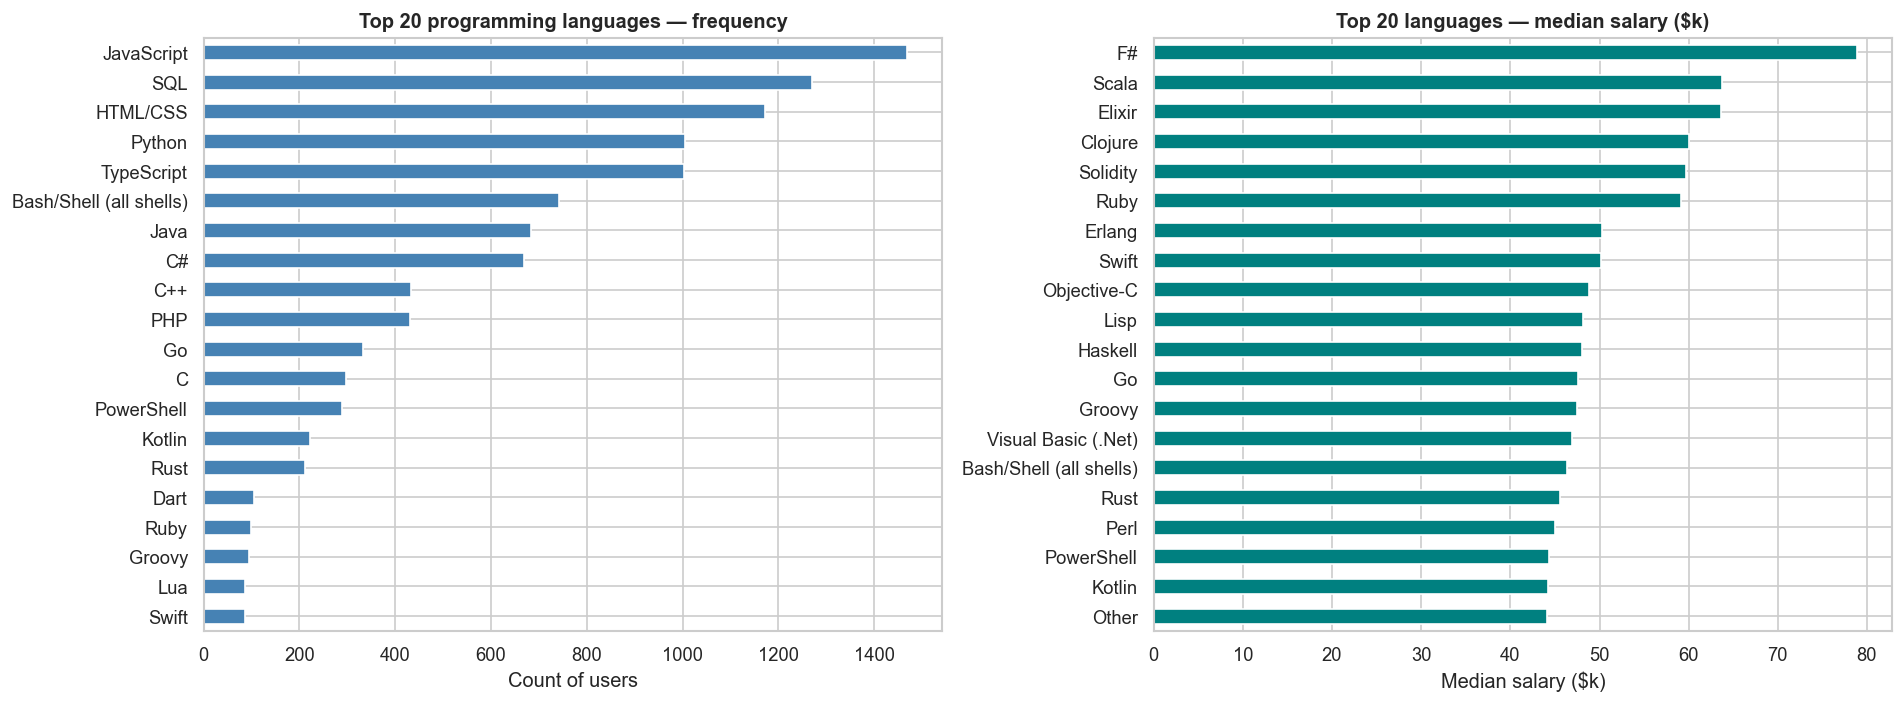

In [26]:
# Programming languages: frequency and median salary
col = 'prog.languages'
top_n = 20

lang_freq = parse_multiselect(df[col])
lang_sal_top = multiselect_salary_analysis(df, col, top_n=top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20_lang = pd.Series(dict(lang_freq.most_common(top_n)))
top20_lang.sort_values(ascending=True).plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top {top_n} programming languages — frequency', fontweight='bold')
axes[0].set_xlabel('Count of users')

lang_sal_top.sort_values('median', ascending=True)['median'].div(1e3).plot.barh(
    ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title(f'Top {top_n} languages — median salary ($k)', fontweight='bold')
axes[1].set_xlabel('Median salary ($k)')

plt.tight_layout()
plt.show()

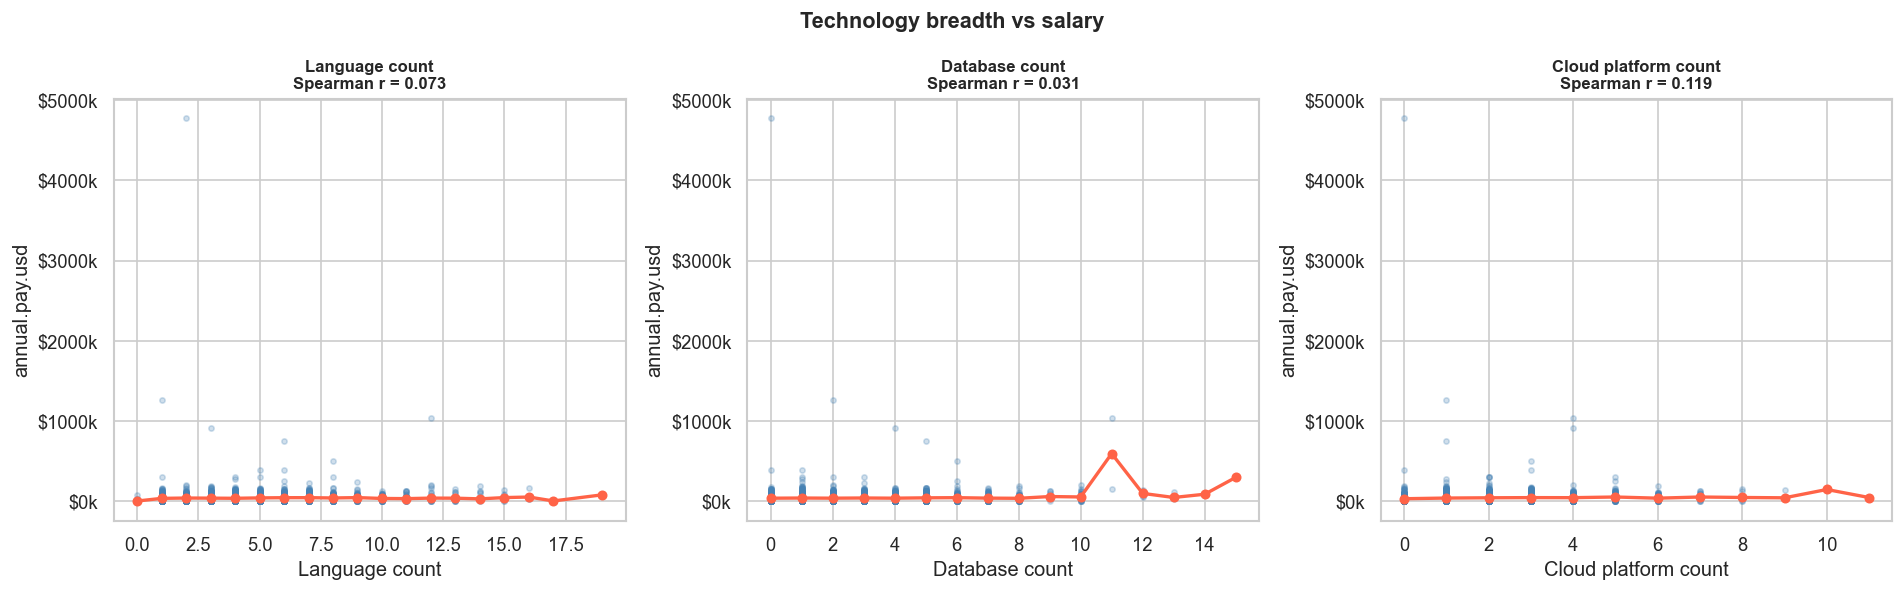

In [27]:
# Technology breadth vs salary: do polyglots earn more?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

count_cols = {
    'prog.languages':  'Language count',
    'databases':       'Database count',
    'cloud.platforms': 'Cloud platform count'
}

for ax, (col, label) in zip(axes, count_cols.items()):
    counts = df[col].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    mask = df[TARGET].notna()
    ax.scatter(counts[mask], df.loc[mask, TARGET], alpha=0.25, s=10, color='steelblue')
    tmp = pd.DataFrame({'cnt': counts[mask], 'sal': df.loc[mask, TARGET]})
    binned = tmp.groupby('cnt')['sal'].median()
    ax.plot(binned.index, binned.values, color='tomato', linewidth=2, marker='o', markersize=5)
    corr = counts[mask].corr(df.loc[mask, TARGET], method='spearman')
    ax.set_title(f'{label}\nSpearman r = {corr:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('annual.pay.usd')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.suptitle('Technology breadth vs salary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

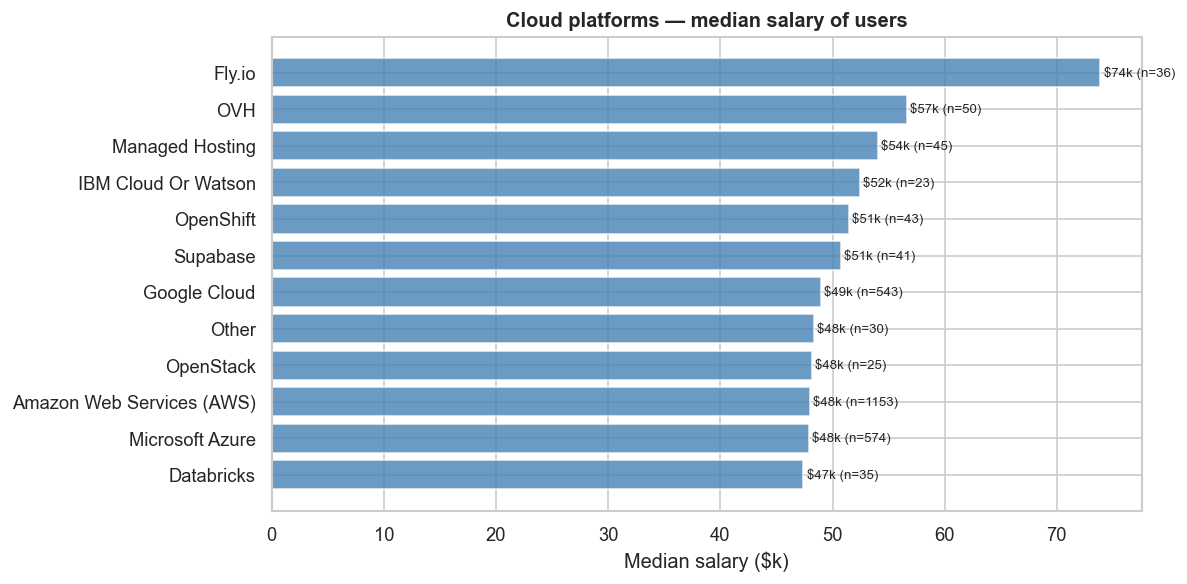

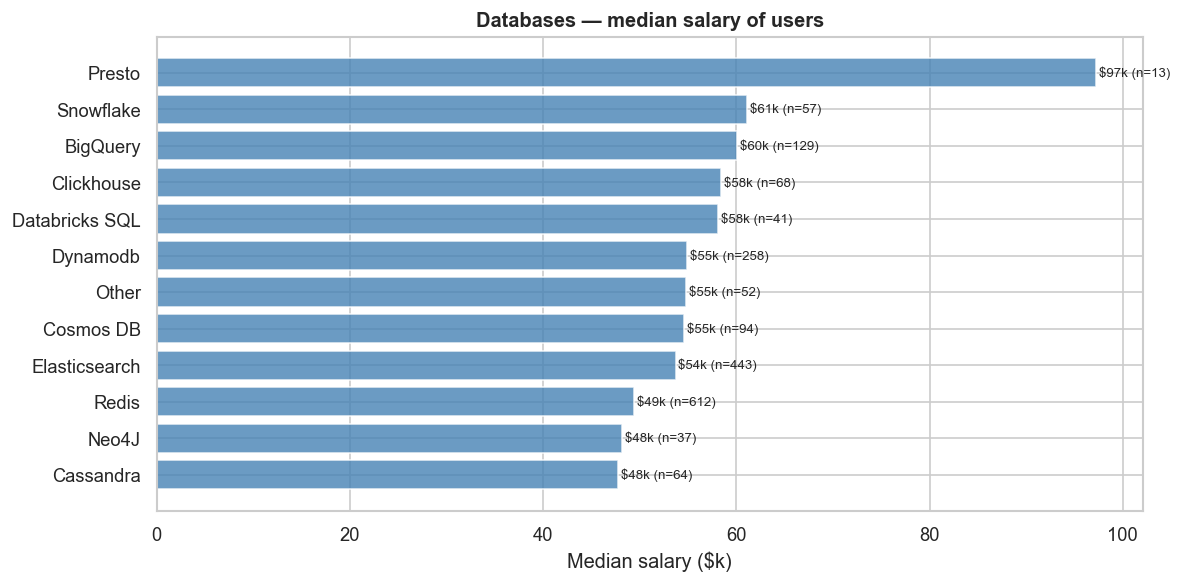

In [28]:
# Cloud platforms and databases: median salary of users
for col, title in [('cloud.platforms', 'Cloud platforms'), ('databases', 'Databases')]:
    top_n = 12
    sal_df = multiselect_salary_analysis(df, col, top_n=top_n)

    fig, ax = plt.subplots(figsize=(10, 5))
    sal_df_sorted = sal_df.sort_values('median')
    bars = ax.barh(sal_df_sorted.index, sal_df_sorted['median'] / 1e3,
                   color='steelblue', edgecolor='white', alpha=0.8)
    for bar, (_, row) in zip(bars, sal_df_sorted.iterrows()):
        ax.text(row['median']/1e3 + 0.3, bar.get_y() + bar.get_height()/2,
                f'${row["median"]/1e3:.0f}k (n={int(row["count"])})', va='center', fontsize=8)
    ax.set_xlabel('Median salary ($k)')
    ax.set_title(f'{title} — median salary of users', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. AI adoption features

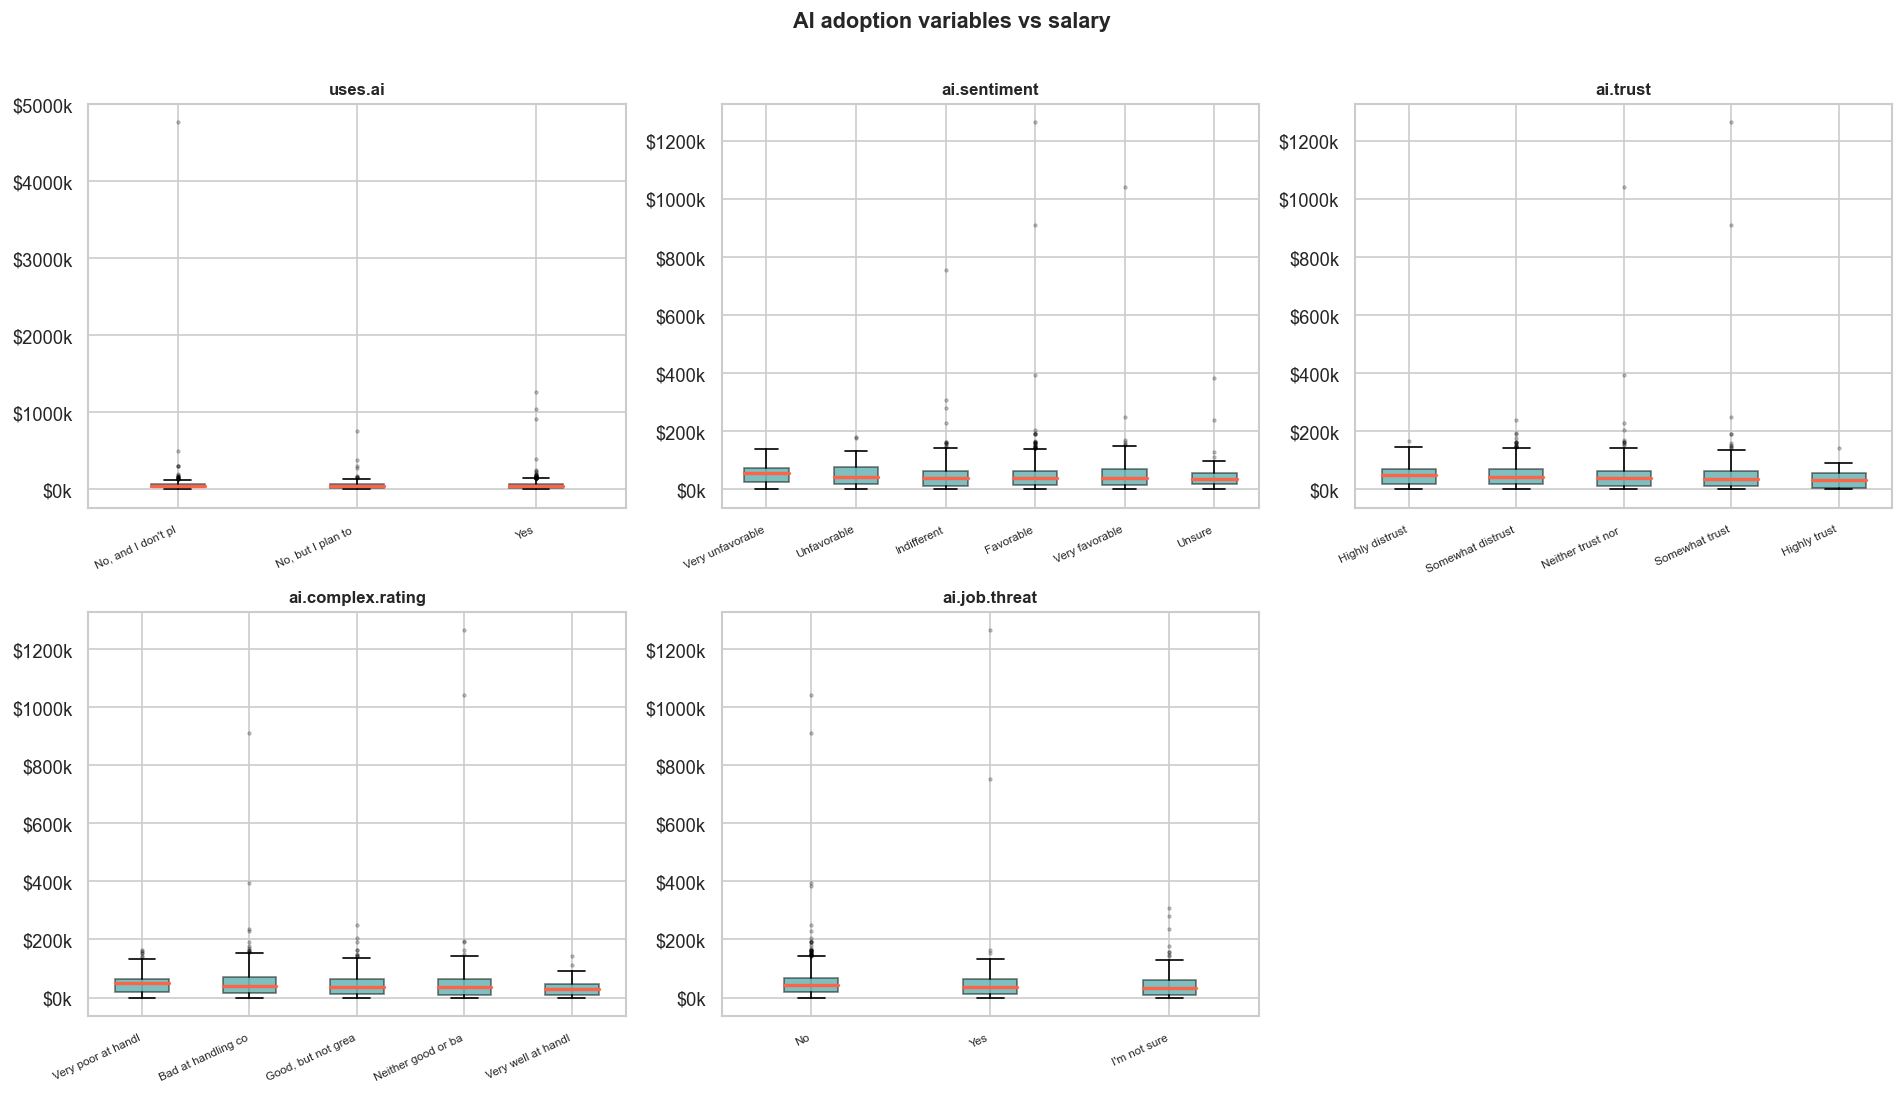

In [29]:
# AI adoption variables vs salary
ai_cols = ['uses.ai', 'ai.sentiment', 'ai.trust', 'ai.complex.rating', 'ai.job.threat']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(ai_cols):
    ax = axes[i]
    order = (df.groupby(col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())
    data_list = [df.loc[df[col] == k, TARGET].dropna() for k in order]
    ax.boxplot(data_list, patch_artist=True,
               boxprops=dict(facecolor='teal', alpha=0.5),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.set_xticklabels([str(k)[:18] for k in order], rotation=25, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

axes[-1].set_visible(False)
plt.suptitle('AI adoption variables vs salary', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

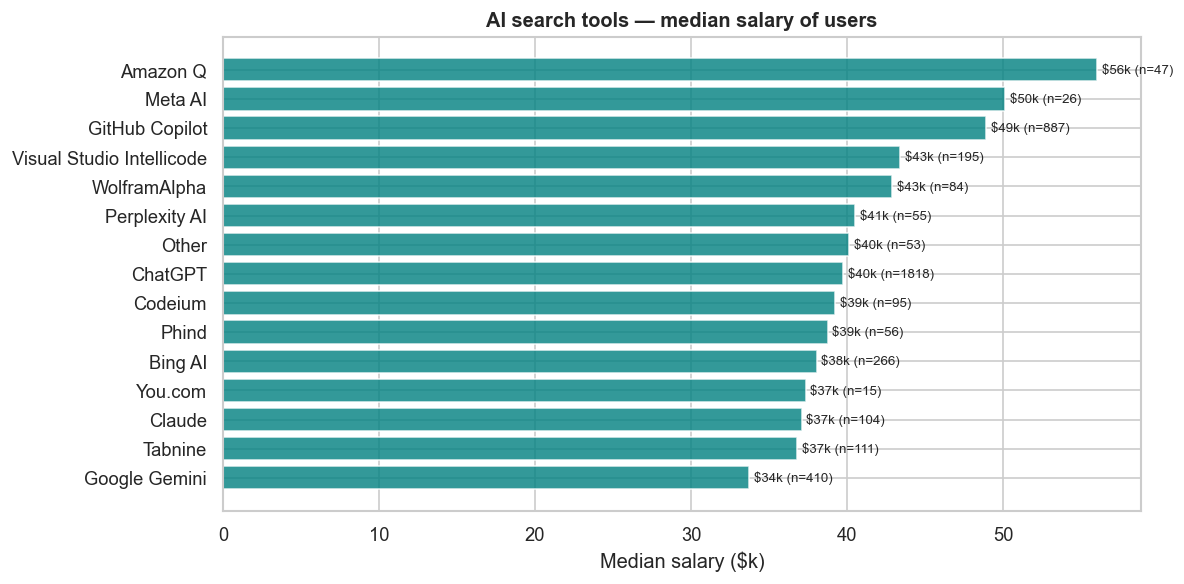

In [30]:
# AI search tools: median salary of users
ai_sal = multiselect_salary_analysis(df, 'ai.search.tools', top_n=15)

fig, ax = plt.subplots(figsize=(10, 5))
ai_sal_sorted = ai_sal.sort_values('median')
ax.barh(ai_sal_sorted.index, ai_sal_sorted['median'] / 1e3,
        color='teal', edgecolor='white', alpha=0.8)
for y, (_, row) in enumerate(ai_sal_sorted.iterrows()):
    ax.text(row['median']/1e3 + 0.3, y,
            f'${row["median"]/1e3:.0f}k (n={int(row["count"])})', va='center', fontsize=8)
ax.set_xlabel('Median salary ($k)')
ax.set_title('AI search tools — median salary of users', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Correlation with target

Region is nominal so Spearman correlation cannot be computed for it. We quantify its association using the **Kruskal-Wallis H statistic** and **eta-squared** — a non-parametric effect size that is directly comparable to R² for continuous features.

In [31]:
# Kruskal-Wallis H and eta-squared for nominal features
n = df[TARGET].notna().sum()

print('Kruskal-Wallis H and eta-squared for nominal features:')
print(f'{"Feature":<30} {"H-stat":>12} {"p-value":>14} {"eta-squared":>13}')
print('-' * 72)
eta2_region = None
for col in ['region', 'employment.type', 'work.location', 'dev.role',
            'people.manager', 'is.dev.professional', 'uses.ai']:
    groups = [df.loc[df[col] == v, TARGET].dropna().values
              for v in df[col].dropna().unique()]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    H, p = stats.kruskal(*groups)
    k_col = len(groups)
    eta2 = max(0, (H - k_col + 1) / (n - k_col))
    if col == 'region':
        eta2_region = eta2
    print(f'{col:<30} {H:>12.1f} {p:>14.2e} {eta2:>13.4f}')

print()
print(f'Region eta-squared = {eta2_region:.4f} — this is a LARGE effect (threshold > 0.14).')
print('Region is the single strongest predictor in the dataset.')

Kruskal-Wallis H and eta-squared for nominal features:
Feature                              H-stat        p-value   eta-squared
------------------------------------------------------------------------
region                                267.1       6.48e-47        0.1003
employment.type                       140.9       1.81e-29        0.0546
work.location                          15.4       4.52e-04        0.0053
dev.role                               95.3       1.97e-11        0.0298
people.manager                         28.6       8.85e-08        0.0110
is.dev.professional                    10.4       1.28e-03        0.0037
uses.ai                                 9.0       1.12e-02        0.0028

Region eta-squared = 0.1003 — this is a LARGE effect (threshold > 0.14).
Region is the single strongest predictor in the dataset.


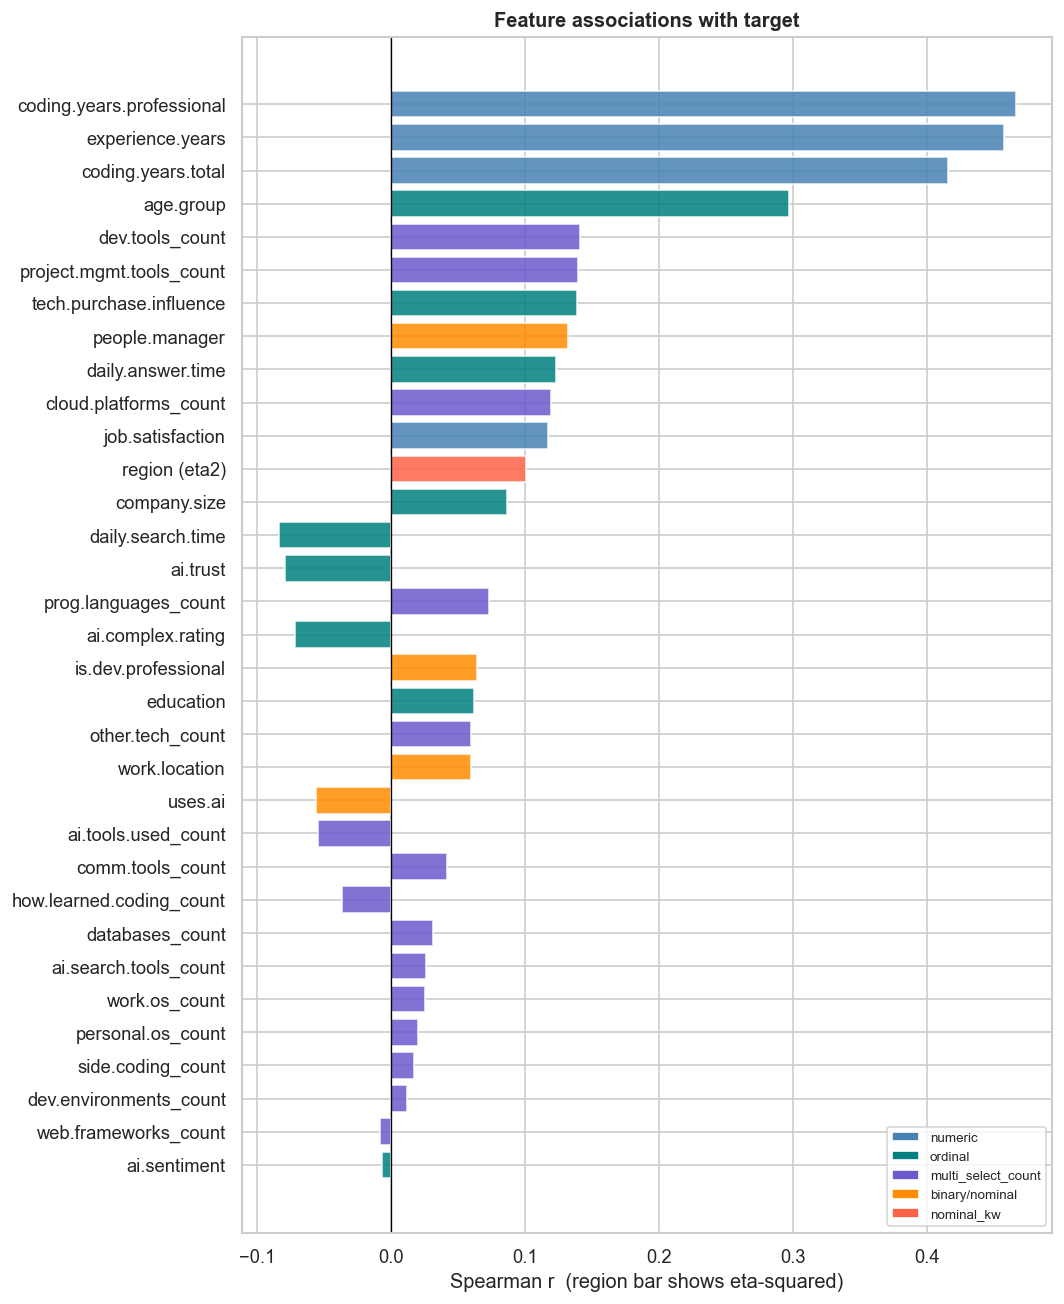

Top 15 features by absolute association with target:
                  feature               type  spearman_r
coding.years.professional            numeric    0.465885
         experience.years            numeric    0.457414
       coding.years.total            numeric    0.415511
                age.group            ordinal    0.296734
          dev.tools_count multi_select_count    0.141083
 project.mgmt.tools_count multi_select_count    0.139435
  tech.purchase.influence            ordinal    0.138287
           people.manager     binary/nominal    0.131603
        daily.answer.time            ordinal    0.122971
    cloud.platforms_count multi_select_count    0.119110
         job.satisfaction            numeric    0.117375
            region (eta2)         nominal_kw    0.100297
             company.size            ordinal    0.086093
        daily.search.time            ordinal   -0.084046
                 ai.trust            ordinal   -0.079478


In [32]:
# Spearman correlation for numeric, ordinal, and multi-select count features
corr_records = []

for col in NUMERIC_COLS:
    r = df[col].corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'numeric', 'spearman_r': r})

for col, mapping in ORDINAL_MAPS.items():
    enc = df[col].map(mapping)
    r = enc.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'ordinal', 'spearman_r': r})

for col in MULTI_SELECT_COLS:
    counts = df[col].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
    r = counts.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col + '_count', 'type': 'multi_select_count', 'spearman_r': r})

for col, cats in [
    ('people.manager',      {'People manager': 1, 'Individual contributor': 0}),
    ('is.dev.professional', {'I am a developer by profession': 1,
                             'I am not primarily a developer, but I write code sometimes as part of my work/studies': 0}),
    ('uses.ai',             {'Yes': 1, 'No, but I plan to soon': 0.5, "No, and I don't plan to": 0}),
    ('work.location',       {'Remote': 2, 'Hybrid (some remote, some in-person)': 1, 'In-person': 0})
]:
    enc = df[col].map(cats)
    r = enc.corr(df[TARGET], method='spearman')
    corr_records.append({'feature': col, 'type': 'binary/nominal', 'spearman_r': r})

# Add region eta-squared as a reference bar
corr_records.append({'feature': 'region (eta2)', 'type': 'nominal_kw', 'spearman_r': eta2_region})

corr_df = (pd.DataFrame(corr_records)
             .sort_values('spearman_r', key=abs, ascending=False)
             .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 11))
palette = {'numeric': 'steelblue', 'ordinal': 'teal', 'multi_select_count': 'slateblue',
           'binary/nominal': 'darkorange', 'nominal_kw': 'tomato'}
bar_colors = [palette.get(t, 'gray') for t in corr_df['type']]
ax.barh(corr_df['feature'], corr_df['spearman_r'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman r  (region bar shows eta-squared)')
ax.set_title('Feature associations with target', fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 15 features by absolute association with target:')
print(corr_df.head(15).to_string(index=False))

## 12. Key findings summary

In [33]:
raw = df[TARGET].dropna()
wins_log_skew = np.log(df_wins[TARGET].dropna()).skew()

print('=' * 70)
print('EDA KEY FINDINGS')
print('=' * 70)
print(f'''
1. TARGET VARIABLE
   Range: ${raw.min():,.0f} – ${raw.max():,.0f}
   Median: ${raw.median():,.0f}  |  Mean: ${raw.mean():,.0f}
   Skewness: raw={raw.skew():.2f} → log={np.log(raw).skew():.2f} → log+winsor={wins_log_skew:.2f}
   ACTION: Model log(winsorized salary). Winsorize per-region at P1/P99.

2. R17 ANOMALY (critical data quality issue)
   R17 = 44% of dataset (n=1,108). Salaries range from $1 to $4.77M
   within a single region — almost certainly currency mixing.
   Per-region winsorization reduces R17 variance the most of all regions.
   ACTION: Winsorize per region. Flag R17 as a region to monitor.

3. MISSING VALUES
   32/41 columns have missing values. 12 columns exceed 30% missing.
   No missing in: region, age.group, employment.type, work.location,
   education, is.dev.professional, uses.ai.
   AI columns (ai.trust, ai.complex.rating, ai.tools.used) are MNAR:
   missing rows earn +11-14% MORE — non-AI users skip these questions.
   ACTION: Median/mode imputation + missingness indicator flags for >10% cols.

4. STRONGEST PREDICTORS
   region                    : eta-squared = {eta2_region:.3f} (dominant, large effect)
   coding.years.professional : Spearman r = 0.47
   experience.years          : Spearman r = 0.46
   coding.years.total        : Spearman r = 0.42  → DROP (collinear)
   age.group                 : Spearman r = 0.30

5. MULTICOLLINEARITY
   coding.years.total vs coding.years.professional : r = 0.86
   experience.years   vs coding.years.professional : r = 0.90
   ACTION: Drop coding.years.total.
   Engineer: years.before.professional = coding.years.total - coding.years.professional

6. MULTI-SELECT COLUMNS
   40 unique languages, 29 databases, 25 cloud platforms, 34 web frameworks.
   Technology breadth (count features) correlates positively with salary.
   ACTION: Binary indicators for top ~20 items + count feature per column.

7. INDUSTRY
   Many categories with n<20. Group rare industries as "Other".

8. MODELING IMPLICATIONS
   Feature matrix will be ~150-200 columns wide after engineering.
   Regularization (Elastic Net, Ridge, LASSO) is essential.
   Scale all features before KNN and SVR.
   Evaluate RMSE on original scale: RMSE(exp(pred), exp(true)).
''')
print('=' * 70)

EDA KEY FINDINGS

1. TARGET VARIABLE
   Range: $1 – $4,773,360
   Median: $40,828  |  Mean: $49,713
   Skewness: raw=33.13 → log=-1.66 → log+winsor=-1.60
   ACTION: Model log(winsorized salary). Winsorize per-region at P1/P99.

2. R17 ANOMALY (critical data quality issue)
   R17 = 44% of dataset (n=1,108). Salaries range from $1 to $4.77M
   within a single region — almost certainly currency mixing.
   Per-region winsorization reduces R17 variance the most of all regions.
   ACTION: Winsorize per region. Flag R17 as a region to monitor.

3. MISSING VALUES
   32/41 columns have missing values. 12 columns exceed 30% missing.
   No missing in: region, age.group, employment.type, work.location,
   education, is.dev.professional, uses.ai.
   AI columns (ai.trust, ai.complex.rating, ai.tools.used) are MNAR:
   missing rows earn +11-14% MORE — non-AI users skip these questions.
   ACTION: Median/mode imputation + missingness indicator flags for >10% cols.

4. STRONGEST PREDICTORS
   region   